# **Model Evaluation**

**MSc thesis Euan Bronsky**

**Notebook number: 4**

This notebook focuses on the evaluation of the various estimated models. Namely, out-of-sample predictions are computed, which are evaluated by MSE and MAE, Diebold-Mariano tests, and Model Confidence Sets. Particular attention is drawn to the statistical significance of model differences.

------------------------

- **Import dependencies**

In [282]:
%reset -f
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from matplotlib.colors import TwoSlopeNorm
import statsmodels.api as sm
import pyfixest as pf

- **Load the data**

In [283]:
# Import data
data = pd.read_parquet("/Users/euanbronsky/Downloads/data_final_final.parquet")

# Locate the correct indices
data_select = data.loc[data.groupby(['quote_date', 'moneyness_group', 'maturity_group'])['distance'].idxmin()]

# Maintain only groups with length 24 and sort the dates
data_select = data_select.groupby('quote_date').filter(lambda x: len(x) == 24)

- **Import model results**

In [284]:
# Basic model
with open("/Users/euanbronsky/PyCharmMiscProject/1first_results.pkl", "rb") as f:
    static_results = pickle.load(f)

# VAR model
with open("/Users/euanbronsky/PyCharmMiscProject/2model1_results.pkl", 'rb') as f:
    var_results = pickle.load(f)

# OU model
with open('/Users/euanbronsky/PyCharmMiscProject/3model_ou_results.pkl', 'rb') as f:
    ou_results = pickle.load(f)

# Spline model
with open("/Users/euanbronsky/PyCharmMiscProject/4spline_results.pkl", "rb") as f:
    spline_results = pickle.load(f)

# NN
with open("/Users/euanbronsky/PyCharmMiscProject/x_test_nn.pkl", "rb") as f:
    nn_results = pickle.load(f)

# **1. IV FORECASTING AND ERROR METRICS**

# **0. Functions**

-------------------------

First, several auxiliary functions are defined to support the empirical analysis. These include functions for constructing heatmaps, preparing the grouped spline inputs, generating implied-volatility predictions, and computing MSE and MAE across different regions of the surface.

- **Heatmap functions**

In [285]:
# Heatmap function
def make_residual_heatmap(data_heatmap, title='Average absolute residuals per group using full contract data', ax=None, show=True, vmin=None, vmax=None):

    # Ensure fixed moneyness and maturity orders
    maturity_order = ["7-45", "45-90", "90-180", "180-360"]
    moneyness_order = ["DOTM_put", "OTM_put", "ATM_put", "ATM_call", "OTM_call", "DOTM_call"]

    # Copy the heatmap data
    data_heatmap = data_heatmap.copy()

    # Convert maturity column into an ordered categorical variable
    data_heatmap['maturity_group'] = pd.Categorical(
        data_heatmap['maturity_group'],
        categories=maturity_order,
        ordered=True)

    # Convert moneyness column into an ordered categorical variable
    data_heatmap['moneyness_group'] = pd.Categorical(
        data_heatmap['moneyness_group'],
        categories=moneyness_order,
        ordered=True)

    # Compute the table for the heatmap
    heatmap_table = data_heatmap.pivot_table(
        values='abs_residual',
        index='maturity_group',
        columns='moneyness_group',
        aggfunc='mean',
        observed=False
    ).reindex(index=maturity_order, columns=moneyness_order)

    # Create a new figure if no axis is provided
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    else:
        fig = ax.figure

    # Draw the actual heatmap
    im = ax.imshow(heatmap_table, aspect='auto', cmap='Blues', vmin=vmin, vmax=vmax)

    # Write the actual numbers inside each heatmap cell
    for i in range(heatmap_table.shape[0]):
        for j in range(heatmap_table.shape[1]):
            ax.text(
                j, i, f"{heatmap_table.iloc[i, j]:.4f}",
                ha="center", va="center")

    # Set several specifics
    ax.invert_yaxis()
    ax.set_xticks(range(len(moneyness_order)))
    ax.set_xticklabels(moneyness_order, rotation=45, ha='right')
    ax.set_yticks(range(len(maturity_order)))
    ax.set_yticklabels(maturity_order)
    ax.set_xlabel('Moneyness group')
    ax.set_ylabel('Maturity group')
    ax.set_title(title)

    # Set the colorbar
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label('Average absolute residual')

    # Only finalize the layout and display the plot if show = True
    if show:
        fig.tight_layout()
        plt.show()

    # Return the table
    return heatmap_table

In [287]:
# Residual heatmap function for state space models
def make_state_model_residual_heatmap(data_source, model_dates, state_array, prepare_groups_function, title='Average absolute residuals per group using full contract data', ax=None, show=True):

    # Only select rows whose quote date is used by the model
    data_heatmap = data_source[data_source['quote_date'].isin(model_dates)].copy()

    # Create ordered categorical variable
    data_heatmap['quote_date'] = pd.Categorical(
        data_heatmap['quote_date'],
        categories=model_dates,
        ordered=True)

    # Sort values
    data_heatmap = data_heatmap.sort_values(['quote_date', 'moneyness_group', 'maturity_group']).copy()

    # Prepare groups and compute predictions
    dates_data, _, Z_groups_data = prepare_groups_function(data_heatmap)
    log_iv_pred, iv_pred = predict_iv(Z_groups_data, state_array[:, :len(dates_data)])

    # Store variables
    data_heatmap['log_iv_pred'] = log_iv_pred
    data_heatmap['iv_pred'] = iv_pred
    data_heatmap['residual'] = data_heatmap['iv_fun'] - data_heatmap['iv_pred']
    data_heatmap['abs_residual'] = np.abs(data_heatmap['residual'])

    # Create heatmap table
    heatmap_table = make_residual_heatmap(data_heatmap, title=title, ax=ax, show=show)

    # Return the results
    return data_heatmap, heatmap_table

- **Prepare groups**

In [288]:
# Group preparing function
def prepare_groups(x):

    # Sort the data
    x = x.sort_values(['quote_date', 'moneyness_group', 'maturity_group']).reset_index(drop=True)

    # Extract dates and create empty lists
    dates = np.sort(x['quote_date'].unique())
    y_groups = []
    Z_groups = []

    # Loop over dates
    for date in dates:

        # Extract groups
        group = x[x['quote_date'] == date]

        # Extract relevant variables and append to lists
        y_groups.append(group['log_iv'].to_numpy(dtype=float))
        Z_groups.append(group[['constant', 'M', 'moneyness_squared', 'T', 'interaction']].to_numpy(dtype=float))

    # return the results
    return dates, y_groups, Z_groups

In [289]:
# Group preparing function
def prepare_groups_spline(x):

    # Sort data
    x = x.sort_values(['quote_date', 'moneyness_group', 'maturity_group']).reset_index(drop=True)

    # Sort the dates
    dates = np.sort(x['quote_date'].unique())

    # Create empty lists
    y_groups = []
    Z_groups = []

    # Loop over the dates
    for date in dates:

        # Extract the groups
        group = x[x['quote_date'] == date]

        # Append the y and Z groups to the lists
        y_groups.append(group['log_iv'].to_numpy(dtype=float))
        Z_groups.append(group[basis_cols].to_numpy(dtype=float))

    # Return the results
    return dates, y_groups, Z_groups

- **Forecast implied volatility**

In [291]:
# Prediction function
def predict_iv(Z_groups, at_pred):

    # Create empty list
    log_iv_pred = []

    # Loop over the number of groups
    for t in range(len(Z_groups)):

        # Extract the group
        Zt = Z_groups[t]

        # Extract the states
        beta_t = at_pred[:, t]

        # Compute predicted values
        log_iv_pred_t = Zt @ beta_t
        log_iv_pred.append(log_iv_pred_t)

    # Concatenate results and compute IV
    log_iv_pred = np.concatenate(log_iv_pred)
    iv_pred = np.exp(log_iv_pred)

    # Return the results
    return log_iv_pred, iv_pred

In [296]:
# Forecasting function for the basic model
def predict_var_iv(x, beta_start, omega, Phi):

    # Sort the data
    x = x.sort_values(['quote_date', 'moneyness_group', 'maturity_group']).copy()

    # Initialize
    beta_prev = beta_start
    log_iv_pred = []
    iv_pred = []

    # Loop over the groups
    for date, group in x.groupby('quote_date'):

        # Forecast today's beta using yesterday's realized beta
        beta_forecast = omega + Phi @ beta_prev

        # Dependent and independent variable
        X = group[['constant', 'M', 'moneyness_squared', 'T', 'interaction']]
        y = group['log_iv']

        # Compute fitted value
        log_pred = X @ beta_forecast

        # Append results to list
        log_iv_pred.append(pd.Series(log_pred, index=group.index, name='log_iv_pred'))
        iv_pred.append(pd.Series(np.exp(log_pred), index=group.index, name='iv_pred'))

        # After observing today's surface, estimate today's realized beta
        beta_prev = sm.OLS(y, X).fit().params.values

    # Return the result
    return pd.concat(iv_pred)

In [292]:
# Prediction function for the full data for the basic static model
def predict_var_iv_full(x_eval, x_bucketed, beta_start, omega, Phi):

    # Sort the values
    x_eval = x_eval.sort_values(
        ["quote_date", "moneyness_group", "maturity_group"]).copy()
    x_bucketed = x_bucketed.sort_values(
        ["quote_date", "moneyness_group", "maturity_group"]).copy()

    # Initialize
    beta_prev = beta_start
    iv_pred = []

    # Loop over the dates
    for date, group_eval in x_eval.groupby("quote_date"):

        # Compute forecast
        beta_forecast = omega + Phi @ beta_prev

        # Obtain regressor matric and prediction
        X_eval = group_eval[["constant", "M", "moneyness_squared", "T", "interaction"]]
        log_pred = X_eval @ beta_forecast

        # Append results to list
        iv_pred.append(pd.Series(np.exp(log_pred), index=group_eval.index, name="iv_pred"))

        # Obtain the bucketed data for the given date
        group_bucket = x_bucketed[x_bucketed["quote_date"] == date]

        # Check whether bucketed data is available for that date
        if len(group_bucket) > 0:

            # Obtain regressors and dependent variable
            X_bucket = group_bucket[["constant", "M", "moneyness_squared", "T", "interaction"]]
            y_bucket = group_bucket["log_iv"]

            # Compute previous beta based on the bucketed data
            beta_prev = sm.OLS(y_bucket, X_bucket).fit().params.values

        # Else use previous forecast
        else:
            beta_prev = beta_forecast

    # Return the predictions
    return pd.concat(iv_pred).sort_index()

- **Align losses**

In [293]:
# Align losses
def align_losses(losses):

    # Initialize common
    common = None

    # Loop over series
    for loss_series in losses.values():

        # Use the first model's dates as the starting set of dates
        if common is None:
            common = loss_series.index

        # Keep only the dates that are already in common
        else:
            common = common.intersection(loss_series.index)

    # Sort values
    common = common.sort_values()

    # Store results in DF
    loss_df = pd.DataFrame({
        name: loss_series.loc[common].to_numpy()
        for name, loss_series in losses.items()
    }, index=common)

    # Return the results
    return loss_df

- **Daily loss function**

In [294]:
# Compute daily losses
def daily_loss(x, pred, loss="mse", group=None):

    # Sort the DataFrame and store predictions
    df = x.sort_values(["quote_date", "moneyness_group", "maturity_group"]).copy()
    df["pred"] = np.asarray(pred)

    # Filter data to one moneyness region if specified
    if group is not None:
        df = df[df["moneyness_group"] == group]

    # Compute the error
    err = df["iv_fun"] - df["pred"]

    # Compute loss metrics
    if loss == "mse":
        l = err ** 2
    elif loss == "mae":
        l = np.abs(err)

    # Return the results which take the daily averages
    return l.groupby(pd.to_datetime(df["quote_date"]).to_numpy()).mean()

# **0. Implied volatility predictions**

---------------------------------

The required data are retrieved, after which forecasted implied volatilities are computed for the testing sample for each model specification. This is done separately for the bucketed data and the full-contract data, allowing the models to be evaluated both on the compressed moneyness-maturity grid and the broader set of option contracts.

- **(M0) Basic model**

In [299]:
# Retrieve data
df_betas_train = static_results["df_betas"]
omega = static_results["omega"]
Phi = static_results["Phi"]
x_test = static_results["x_test"]
x_train = static_results["x_train"]

# Compute bucketed predictions
iv_pred_basic = predict_var_iv(x_test, df_betas_train.iloc[-1].values, omega, Phi)

# Prepare full data
x_test_full_first = data[data["quote_date"].isin(x_test["quote_date"].unique())].copy()
x_test_full_first = x_test_full_first.sort_values(["quote_date", "moneyness_group", "maturity_group"]).copy()

# Compute full-contract predictions
iv_pred_first_full = predict_var_iv_full(x_eval=x_test_full_first, x_bucketed=x_test, beta_start=df_betas_train.iloc[-1].values, omega=omega, Phi=Phi)

- **(M1) VAR model**

In [300]:
# Retrieve data
at_pred_var = var_results["at_pred"]
x_train_var = var_results["x_train"]
x_test_var = var_results["x_test"]

# Prepare data
dates_train_var, _, _ = prepare_groups(x_train_var)
n_train_dates_var = len(dates_train_var)
dates_test_var, _, Z_groups_test_var = prepare_groups(x_test_var)

# Compute predictions
log_iv_pred_test_var, iv_pred_test_var = predict_iv(Z_groups_test_var, at_pred_var[:, n_train_dates_var:n_train_dates_var + len(dates_test_var)])

# Prepare data
x_test_full_var = data[data["quote_date"].isin(dates_test_var)].copy()
x_test_full_var = x_test_full_var.sort_values(["quote_date", "moneyness_group", "maturity_group"]).copy()
dates_test_full_var, _, Z_groups_test_full_var = prepare_groups(x_test_full_var)

# Compute full-contract predictions
log_iv_pred_test_full_var, iv_pred_test_full_var = predict_iv(Z_groups_test_full_var, at_pred_var[:, n_train_dates_var:n_train_dates_var + len(dates_test_full_var)])

- **(M2) OU model**

In [301]:
# Retrieve data
at_pred_ou = ou_results["at_pred"]

# Prepare data
dates_train_ou, _, _ = prepare_groups(x_train)
n_train_dates_ou = len(dates_train_ou)
dates_test_ou, _, Z_groups_test_ou = prepare_groups(x_test)

# Compute bucketed predictions
log_iv_pred_test_ou, iv_pred_test_ou = predict_iv(Z_groups_test_ou, at_pred_ou[:, n_train_dates_ou:n_train_dates_ou + len(dates_test_ou)])

# Prepare full contract data
x_test_full_ou = data[data["quote_date"].isin(dates_test_ou)].copy()
x_test_full_ou = x_test_full_ou.sort_values(["quote_date", "moneyness_group", "maturity_group"]).copy()
dates_test_full_ou, _, Z_groups_test_full_ou = prepare_groups(x_test_full_ou)

# Compute full-contract data predictions
log_iv_pred_test_full_ou, iv_pred_test_full_ou = predict_iv(Z_groups_test_full_ou, at_pred_ou[:, n_train_dates_ou:n_train_dates_ou + len(dates_test_full_ou)])

- **(M3) Spline model**

In [302]:
# Retrieve data
at_pred_spline = spline_results["at_pred"]
x_train_spline = spline_results["x_train_spline"]
x_test_spline = spline_results["x_test_spline"]
basis_cols = spline_results["basis_cols"]
data_spline_full = spline_results["data_spline_full"]

# Prepare data
dates_train_spline, _, _ = prepare_groups_spline(x_train_spline)
n_train_dates_spline = len(dates_train_spline)
dates_test_spline, _, Z_groups_test_spline = prepare_groups_spline(x_test_spline)

# Compute bucketed predictions
log_iv_pred_test_spline, iv_pred_test_spline = predict_iv(Z_groups_test_spline,at_pred_spline[:, n_train_dates_spline:n_train_dates_spline + len(dates_test_spline)])

# Prepare full contract data
x_test_full_spline = data_spline_full[data_spline_full["quote_date"].isin(dates_test_spline)].copy()
x_test_full_spline = x_test_full_spline.sort_values(["quote_date", "moneyness_group", "maturity_group"]).copy()
dates_test_full_spline, _, Z_groups_test_full_spline = prepare_groups_spline(x_test_full_spline)

# Compute full contract data predictions
log_iv_pred_test_full_spline, iv_pred_test_full_spline = predict_iv(Z_groups_test_full_spline, at_pred_spline[:, n_train_dates_spline:n_train_dates_spline + len(dates_test_full_spline)])

- **(M4) Smoother model**

Predictions for the Smoother model have already been computed in notebook number 3.

In [303]:
# Retrieve data
x_test_nn = nn_results["x_test_nn"]
x_test_nn_eval = x_test_nn.sort_values(["quote_date", "moneyness_group", "maturity_group"]).copy()
iv_pred_test_nn = x_test_nn_eval["iv_nn"].to_numpy()

# **1. Align losses**
-------------------------
To ensure comparability across model specifications, a common testing sample is constructed. This is necessary because the testing sample for the spline-based models differs slightly from that of the competing models. Therefore, valid comparison of the loss metrics requires all models to be evaluated on exactly the same observations. The losses are first computed using the daily loss function and are subsequently aligned using the loss-alignment function.

- **Bucketed losses**

In [304]:
# Bucketed MSE
losses_bucketed_mse = {
    "Basic": daily_loss(x_test, iv_pred_basic, loss="mse"),
    "VAR": daily_loss(x_test_var, iv_pred_test_var, loss="mse"),
    "OU": daily_loss(x_test, iv_pred_test_ou, loss="mse"),
    "Spline": daily_loss(x_test_spline, iv_pred_test_spline, loss="mse")}

# Bucketed MAE
losses_bucketed_mae = {
    "Basic": daily_loss(x_test, iv_pred_basic, loss="mae"),
    "VAR": daily_loss(x_test_var, iv_pred_test_var, loss="mae"),
    "OU": daily_loss(x_test, iv_pred_test_ou, loss="mae"),
    "Spline": daily_loss(x_test_spline, iv_pred_test_spline, loss="mae")}

- **Full losses**

In [305]:
# Full MSE
losses_full_mse = {
    "VAR": daily_loss(x_test_full_var, iv_pred_test_full_var, loss="mse"),
    "OU": daily_loss(x_test_full_ou, iv_pred_test_full_ou, loss="mse"),
    "Spline": daily_loss(x_test_full_spline, iv_pred_test_full_spline, loss="mse"),
    "NN": daily_loss(x_test_nn_eval, iv_pred_test_nn, loss="mse")}

# Full MAE
losses_full_mae = {
    "VAR": daily_loss(x_test_full_var, iv_pred_test_full_var, loss="mae"),
    "OU": daily_loss(x_test_full_ou, iv_pred_test_full_ou, loss="mae"),
    "Spline": daily_loss(x_test_full_spline, iv_pred_test_full_spline, loss="mae"),
    "NN": daily_loss(x_test_nn_eval, iv_pred_test_nn, loss="mae")}

- **Align losses**

In [308]:
# Align bucketed losses
loss_df_bucketed_mse = align_losses(losses_bucketed_mse)
loss_df_bucketed_mae = align_losses(losses_bucketed_mae)

# Align full losses
loss_df_full_mse = align_losses(losses_full_mse)
loss_df_full_mae = align_losses(losses_full_mae)

# **2. Compute MSE and MAE**
------------------------
The error metrics used are the mean squared error (MSE) and mean absolute error (MAE). The MSE gives relatively more weight to large errors, while the MAE measures teh average absolute forecasting error and is easy to interpret. Together, these metrics mae it possible to assess both the typical size of the forecast errors and the extent to which large deviations affect model performance.

\begin{equation}
\begin{aligned}
MAE^{(m)}
&=
\frac{1}{N_0} \sum_{t\in \mathcal{T}_{train}}\frac{1}{N_t}\sum_{(\tau_i, m_i) \in \mathcal{I}_{0,t}}
\left|
\sigma_{i,t+1}(\tau_i, m_i)
-
\hat{\sigma}^{(m)}_{i,t+1}(\tau_i, m_i)
\right|, \\ MSE^{(m)}
&=
\frac{1}{N_0} \sum_{t\in \mathcal{T}_{train}}\frac{1}{N_t} \sum_{(\tau_i,m_i)\in \mathcal{I}_{0,t}}
\left(
\sigma_{i,t+1}(\tau_i, m_i)
-
\hat{\sigma}^{(m)}_{i,t+1}(\tau_i, m_i)
\right)^2
\end{aligned}
\end{equation}

The losses are first averaged within each day, so that days with more available option contracts do not receive disproportionate weight. The daily losses are then averaged over the full testing period, yielding one overall MAE and MSE value for each model specification.

- **Bucketed data aggregate results**

In [310]:
# Extract dates ad create COVID mask
dates = pd.Series(pd.to_datetime(loss_df_bucketed_mse.index), index=loss_df_bucketed_mse.index)
covid = dates.between("2020-01-01", "2022-12-31")

# Create small results table for selected period
def results_table(mse_df, mae_df, mask):
    return pd.DataFrame({
        "MSE": mse_df.loc[mask].mean(),
        "MAE": mae_df.loc[mask].mean()
    })

# Full sample
print("\nFull sample")
print(results_table(loss_df_bucketed_mse, loss_df_bucketed_mae, dates == dates))

# Non-COVID
print("\nNon-COVID")
print(results_table(loss_df_bucketed_mse, loss_df_bucketed_mae, ~covid))

# COVID
print("\nCOVID")
print(results_table(loss_df_bucketed_mse, loss_df_bucketed_mae, covid))


Full sample
             MSE       MAE
Basic   0.000216  0.010116
VAR     0.000240  0.010558
OU      0.000247  0.010686
Spline  0.000181  0.008372

Non-COVID
             MSE       MAE
Basic   0.000092  0.007243
VAR     0.000101  0.007554
OU      0.000104  0.007633
Spline  0.000072  0.005888

COVID
             MSE       MAE
Basic   0.000287  0.011759
VAR     0.000319  0.012275
OU      0.000328  0.012431
Spline  0.000244  0.009792


- **Bucketed data region-specific (DOTM put) results**

In [311]:
# Specify region
region = "DOTM_put"

# Align losses MSE
loss_region_bucketed_mse = align_losses({
    "Basic": daily_loss(x_test, iv_pred_basic, "mse", group=region),
    "VAR": daily_loss(x_test_var, iv_pred_test_var, "mse", group=region),
    "OU": daily_loss(x_test, iv_pred_test_ou, "mse", group=region),
    "Spline": daily_loss(x_test_spline, iv_pred_test_spline, "mse", group=region)})

# Align losses MAE
loss_region_bucketed_mae = align_losses({
    "Basic": daily_loss(x_test, iv_pred_basic, "mae", group=region),
    "VAR": daily_loss(x_test_var, iv_pred_test_var, "mae", group=region),
    "OU": daily_loss(x_test, iv_pred_test_ou, "mae", group=region),
    "Spline": daily_loss(x_test_spline, iv_pred_test_spline, "mae", group=region)})

# Full sample
print(f"\n{region} - Full sample")
print(results_table(loss_region_bucketed_mse, loss_region_bucketed_mae, dates == dates))

# Non-COVID
print(f"\n{region} - Non-COVID")
print(results_table(loss_region_bucketed_mse, loss_region_bucketed_mae, ~covid))

# COVID
print(f"\n{region} - COVID")
print(results_table(loss_region_bucketed_mse, loss_region_bucketed_mae, covid))


DOTM_put - Full sample
             MSE       MAE
Basic   0.000240  0.010994
VAR     0.000313  0.012213
OU      0.000313  0.011458
Spline  0.000312  0.010392

DOTM_put - Non-COVID
             MSE       MAE
Basic   0.000110  0.008462
VAR     0.000138  0.009121
OU      0.000123  0.008045
Spline  0.000098  0.006610

DOTM_put - COVID
             MSE       MAE
Basic   0.000314  0.012442
VAR     0.000413  0.013981
OU      0.000422  0.013410
Spline  0.000434  0.012555


- **Full-contract data aggregate results**

In [312]:
# Excluding 2023 mask
excl_2023 = dates.dt.year != 2023

# Full sample
print("\nFull sample")
print(results_table(loss_df_full_mse, loss_df_full_mae, dates == dates))

# COVID
print("\nCOVID")
print(results_table(loss_df_full_mse, loss_df_full_mae, covid))

# Excluding 2023
print("\nExcl. 2023")
print(results_table(loss_df_full_mse, loss_df_full_mae, excl_2023))


Full sample
             MSE       MAE
VAR     0.280793  0.041730
OU      0.009923  0.038362
Spline  0.006772  0.034849
NN      0.000594  0.014155

COVID
             MSE       MAE
VAR     0.012248  0.041979
OU      0.013082  0.045743
Spline  0.006238  0.033858
NN      0.000826  0.017110

Excl. 2023
             MSE       MAE
VAR     0.010317  0.038062
OU      0.011090  0.041536
Spline  0.006905  0.036046
NN      0.000699  0.015477


- **Full-contract data region-specific (DOTM put) results**

In [313]:
# Align MSE losses
loss_region_full_mse = align_losses({
    "VAR": daily_loss(x_test_full_var, iv_pred_test_full_var, "mse", group=region),
    "OU": daily_loss(x_test_full_ou, iv_pred_test_full_ou, "mse", group=region),
    "Spline": daily_loss(x_test_full_spline, iv_pred_test_full_spline, "mse", group=region),
    "NN": daily_loss(x_test_nn_eval, iv_pred_test_nn, "mse", group=region)})

# Align MAE losses
loss_region_full_mae = align_losses({
    "VAR": daily_loss(x_test_full_var, iv_pred_test_full_var, "mae", group=region),
    "OU": daily_loss(x_test_full_ou, iv_pred_test_full_ou, "mae", group=region),
    "Spline": daily_loss(x_test_full_spline, iv_pred_test_full_spline, "mae", group=region),
    "NN": daily_loss(x_test_nn_eval, iv_pred_test_nn, "mae", group=region)})

# Full sample
print(f"\n{region} - Full sample")
print(results_table(loss_region_full_mse, loss_region_full_mae, dates == dates))

# COVID
print(f"\n{region} - COVID")
print(results_table(loss_region_full_mse, loss_region_full_mae, covid))

# Non-COVID
print(f"\n{region} - Excl. 2023")
print(results_table(loss_region_full_mse, loss_region_full_mae, excl_2023))


DOTM_put - Full sample
             MSE       MAE
VAR     0.658353  0.084960
OU      0.026722  0.076677
Spline  0.019474  0.081387
NN      0.001493  0.024986

DOTM_put - COVID
             MSE       MAE
VAR     0.033612  0.084185
OU      0.035572  0.093071
Spline  0.018664  0.078712
NN      0.002137  0.031784

DOTM_put - Excl. 2023
             MSE       MAE
VAR     0.028170  0.074962
OU      0.029995  0.083173
Spline  0.019859  0.083254
NN      0.001775  0.027786


# **4. Heatmaps**
--------------------------

To provide a visual interpretation for the error metrics, heatmaps are created. This allows for a direct comparison of forecasting errors across moneyness and maturity groups and makes it possible to identify whether model improvements are concentrated in specific regions of the implied volatility surface.

- **(M0) Basic model**

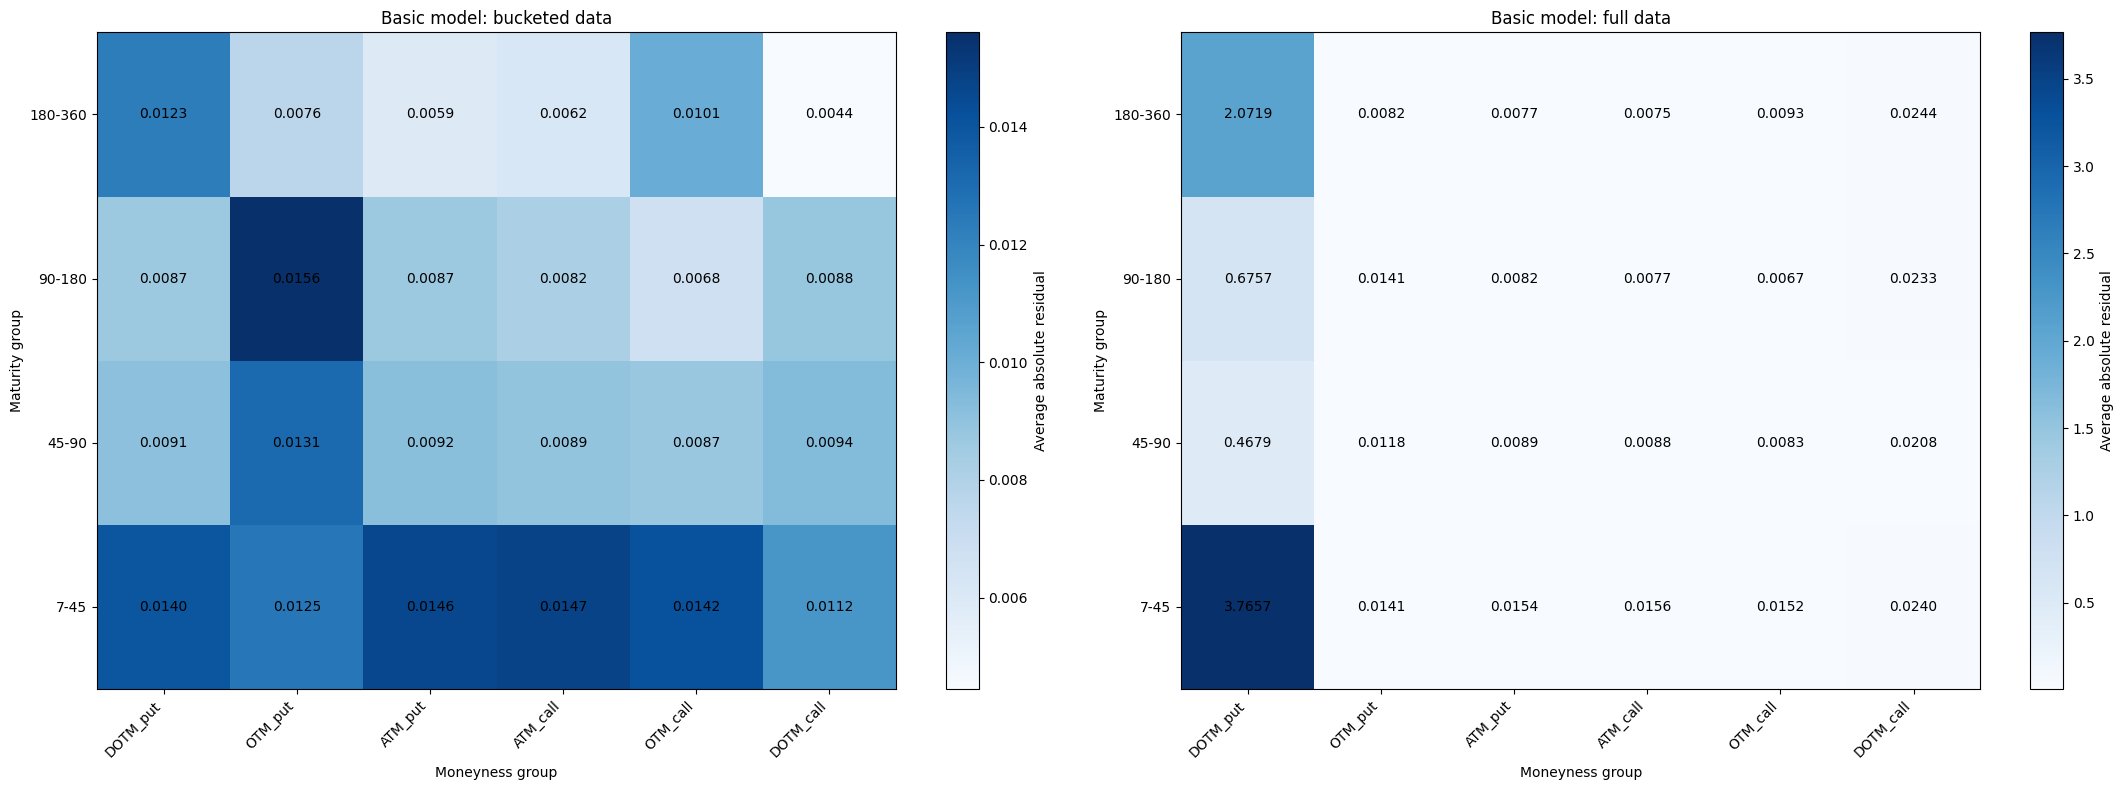

In [314]:
# Extract dates
bucketed_dates = loss_df_bucketed_mse.index
full_dates = loss_df_full_mse.index

# Bucketed data
mask_bucketed = x_test["quote_date"].isin(bucketed_dates)

# Compute average residuals for bucketed data
df_basic_bucketed = x_test.loc[mask_bucketed].copy()
df_basic_bucketed["iv_pred"] = np.asarray(iv_pred_basic)[mask_bucketed]
df_basic_bucketed["residual"] = df_basic_bucketed["iv_fun"] - df_basic_bucketed["iv_pred"]
df_basic_bucketed["abs_residual"] = np.abs(df_basic_bucketed["residual"])

# Full-contract data
mask_full = x_test_full_first["quote_date"].isin(full_dates)

# Compute average residuals for full contract data
df_basic_full = x_test_full_first.loc[mask_full].copy()
df_basic_full["iv_pred"] = np.asarray(iv_pred_first_full)[mask_full]
df_basic_full["residual"] = df_basic_full["iv_fun"] - df_basic_full["iv_pred"]
df_basic_full["abs_residual"] = np.abs(df_basic_full["residual"])

# Set plotting environment
fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# Call heatmap functions
make_residual_heatmap(df_basic_bucketed, "Basic model: bucketed data", ax=axes[0], show=False)
make_residual_heatmap(df_basic_full, "Basic model: full data", ax=axes[1], show=False)

# Plot the results
fig.tight_layout()
plt.savefig("/Users/euanbronsky/Downloads/heatmap.basic2.png", bbox_inches="tight")
plt.show()

- **(M1) VAR model**

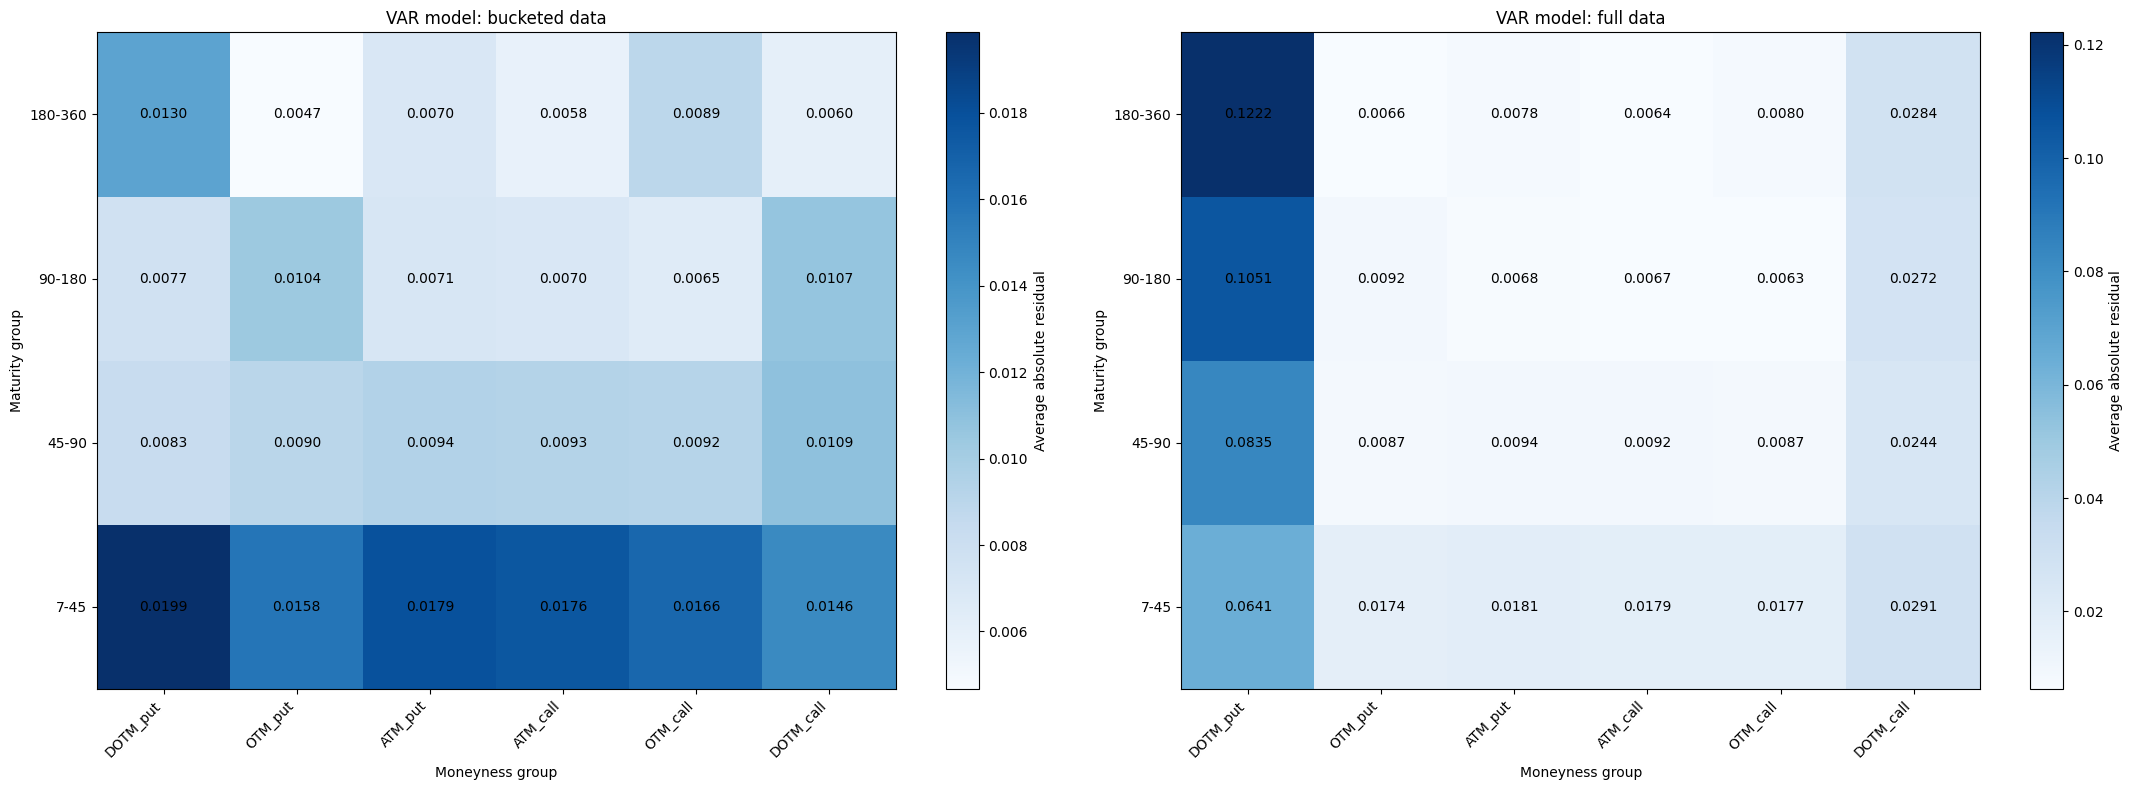

In [315]:
# Bucketed mask
mask_bucketed = x_test_var["quote_date"].isin(bucketed_dates)

# Compute average residuals
df_var_bucketed = x_test_var.loc[mask_bucketed].copy()
df_var_bucketed["iv_pred"] = np.asarray(iv_pred_test_var)[mask_bucketed]
df_var_bucketed["residual"] = df_var_bucketed["iv_fun"] - df_var_bucketed["iv_pred"]
df_var_bucketed["abs_residual"] = np.abs(df_var_bucketed["residual"])

# Full mask
mask_full = x_test_full_var["quote_date"].isin(full_dates)

# Compute average residuals
df_var_full = x_test_full_var.loc[mask_full].copy()
df_var_full["iv_pred"] = np.asarray(iv_pred_test_full_var)[mask_full]
df_var_full["residual"] = df_var_full["iv_fun"] - df_var_full["iv_pred"]
df_var_full["abs_residual"] = np.abs(df_var_full["residual"])

# Set plotting environment
fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# Call the heatmap functions
make_residual_heatmap(df_var_bucketed, "VAR model: bucketed data", ax=axes[0], show=False)
make_residual_heatmap(df_var_full, "VAR model: full data", ax=axes[1], show=False)

# Plot the results
fig.tight_layout()
plt.savefig("/Users/euanbronsky/Downloads/heatmap.VAR2.png", bbox_inches="tight")
plt.show()

- **(M2) OU model**

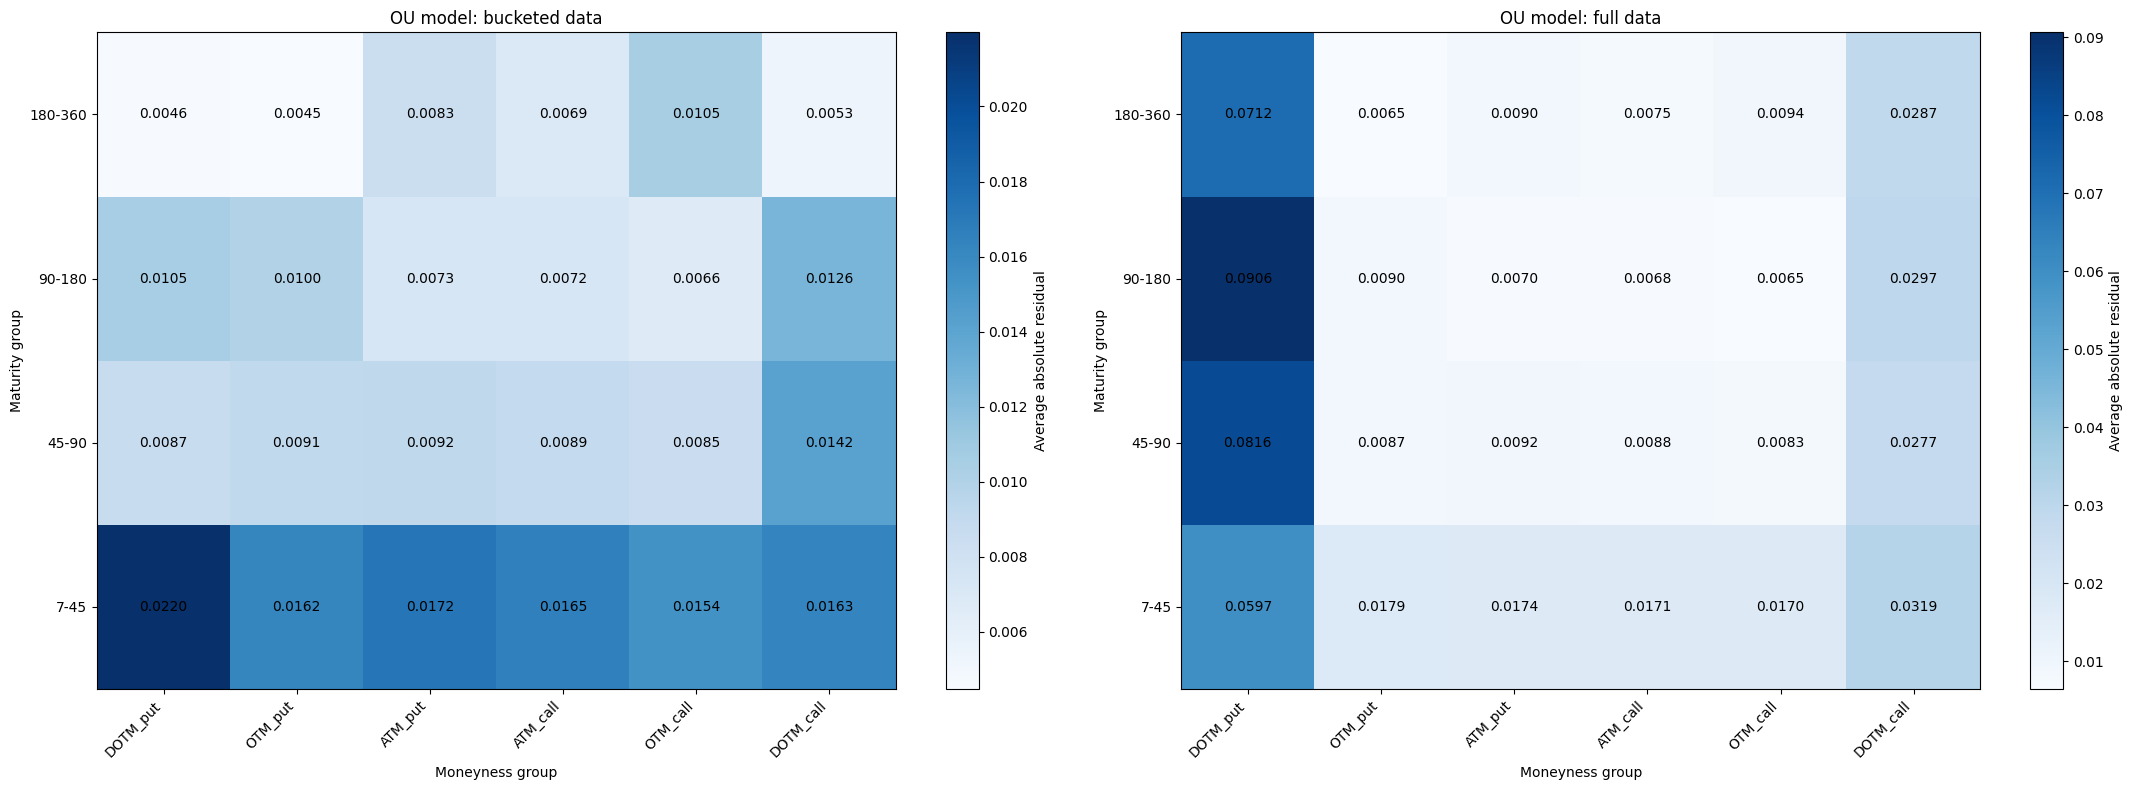

In [316]:
# Bucketed mask
mask_bucketed = x_test["quote_date"].isin(bucketed_dates)

# Average residuals
df_ou_bucketed = x_test.loc[mask_bucketed].copy()
df_ou_bucketed["iv_pred"] = np.asarray(iv_pred_test_ou)[mask_bucketed]
df_ou_bucketed["residual"] = df_ou_bucketed["iv_fun"] - df_ou_bucketed["iv_pred"]
df_ou_bucketed["abs_residual"] = np.abs(df_ou_bucketed["residual"])

# Full mask
mask_full = x_test_full_ou["quote_date"].isin(full_dates)

# Compute average residuals
df_ou_full = x_test_full_ou.loc[mask_full].copy()
df_ou_full["iv_pred"] = np.asarray(iv_pred_test_full_ou)[mask_full]
df_ou_full["residual"] = df_ou_full["iv_fun"] - df_ou_full["iv_pred"]
df_ou_full["abs_residual"] = np.abs(df_ou_full["residual"])

# Set plotting environment
fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# Call heatmap functions
make_residual_heatmap(df_ou_bucketed, "OU model: bucketed data", ax=axes[0], show=False)
make_residual_heatmap(df_ou_full, "OU model: full data", ax=axes[1], show=False)

# Plot the results
fig.tight_layout()
plt.savefig("/Users/euanbronsky/Downloads/heatmap.OU2.png", bbox_inches="tight")
plt.show()

- **(M3) Spline model**

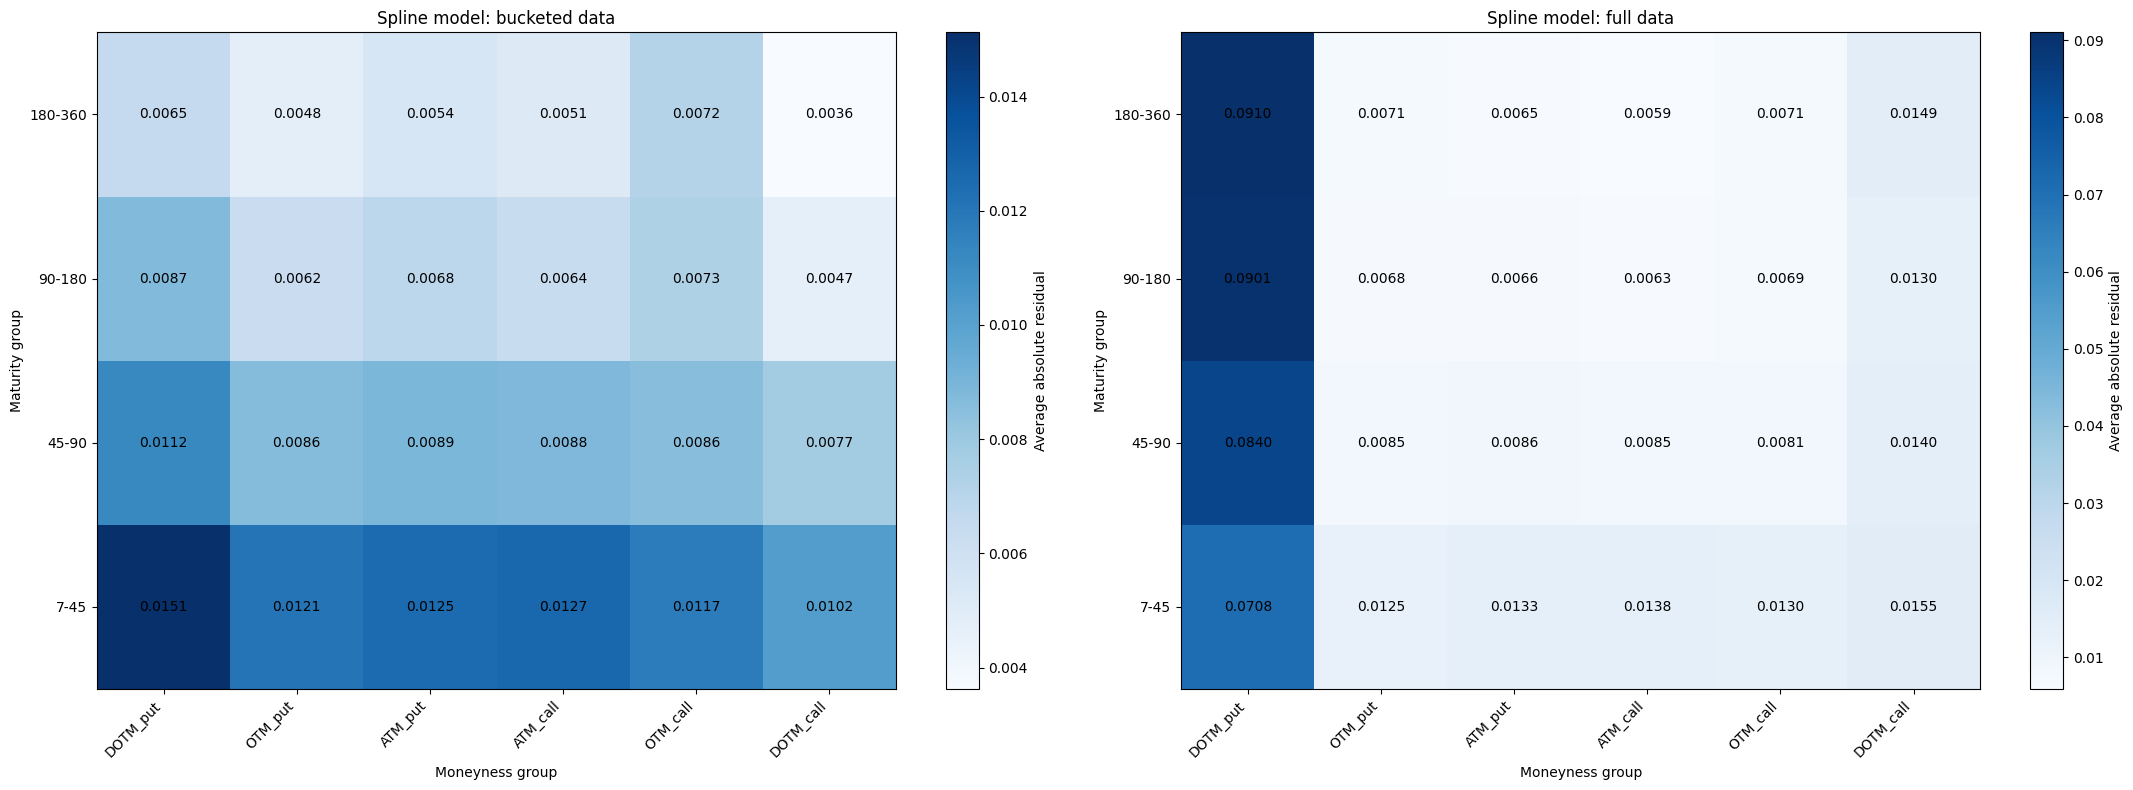

In [317]:
# Bucketed mask
mask_bucketed = x_test_spline["quote_date"].isin(bucketed_dates)

# Compute average residuals
df_spline_bucketed = x_test_spline.loc[mask_bucketed].copy()
df_spline_bucketed["iv_pred"] = np.asarray(iv_pred_test_spline)[mask_bucketed]
df_spline_bucketed["residual"] = df_spline_bucketed["iv_fun"] - df_spline_bucketed["iv_pred"]
df_spline_bucketed["abs_residual"] = np.abs(df_spline_bucketed["residual"])

# Full mask
mask_full = x_test_full_spline["quote_date"].isin(full_dates)

# Compute average residuals
df_spline_full = x_test_full_spline.loc[mask_full].copy()
df_spline_full["iv_pred"] = np.asarray(iv_pred_test_full_spline)[mask_full]
df_spline_full["residual"] = df_spline_full["iv_fun"] - df_spline_full["iv_pred"]
df_spline_full["abs_residual"] = np.abs(df_spline_full["residual"])

# Set plotting environment
fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# Call heatmap functions
make_residual_heatmap(df_spline_bucketed, "Spline model: bucketed data", ax=axes[0], show=False)
make_residual_heatmap(df_spline_full, "Spline model: full data", ax=axes[1], show=False)

# Plot the results
fig.tight_layout()
plt.savefig("/Users/euanbronsky/Downloads/heatmap.spline2.png", bbox_inches="tight")
plt.show()

- **(M4) Smoother model**

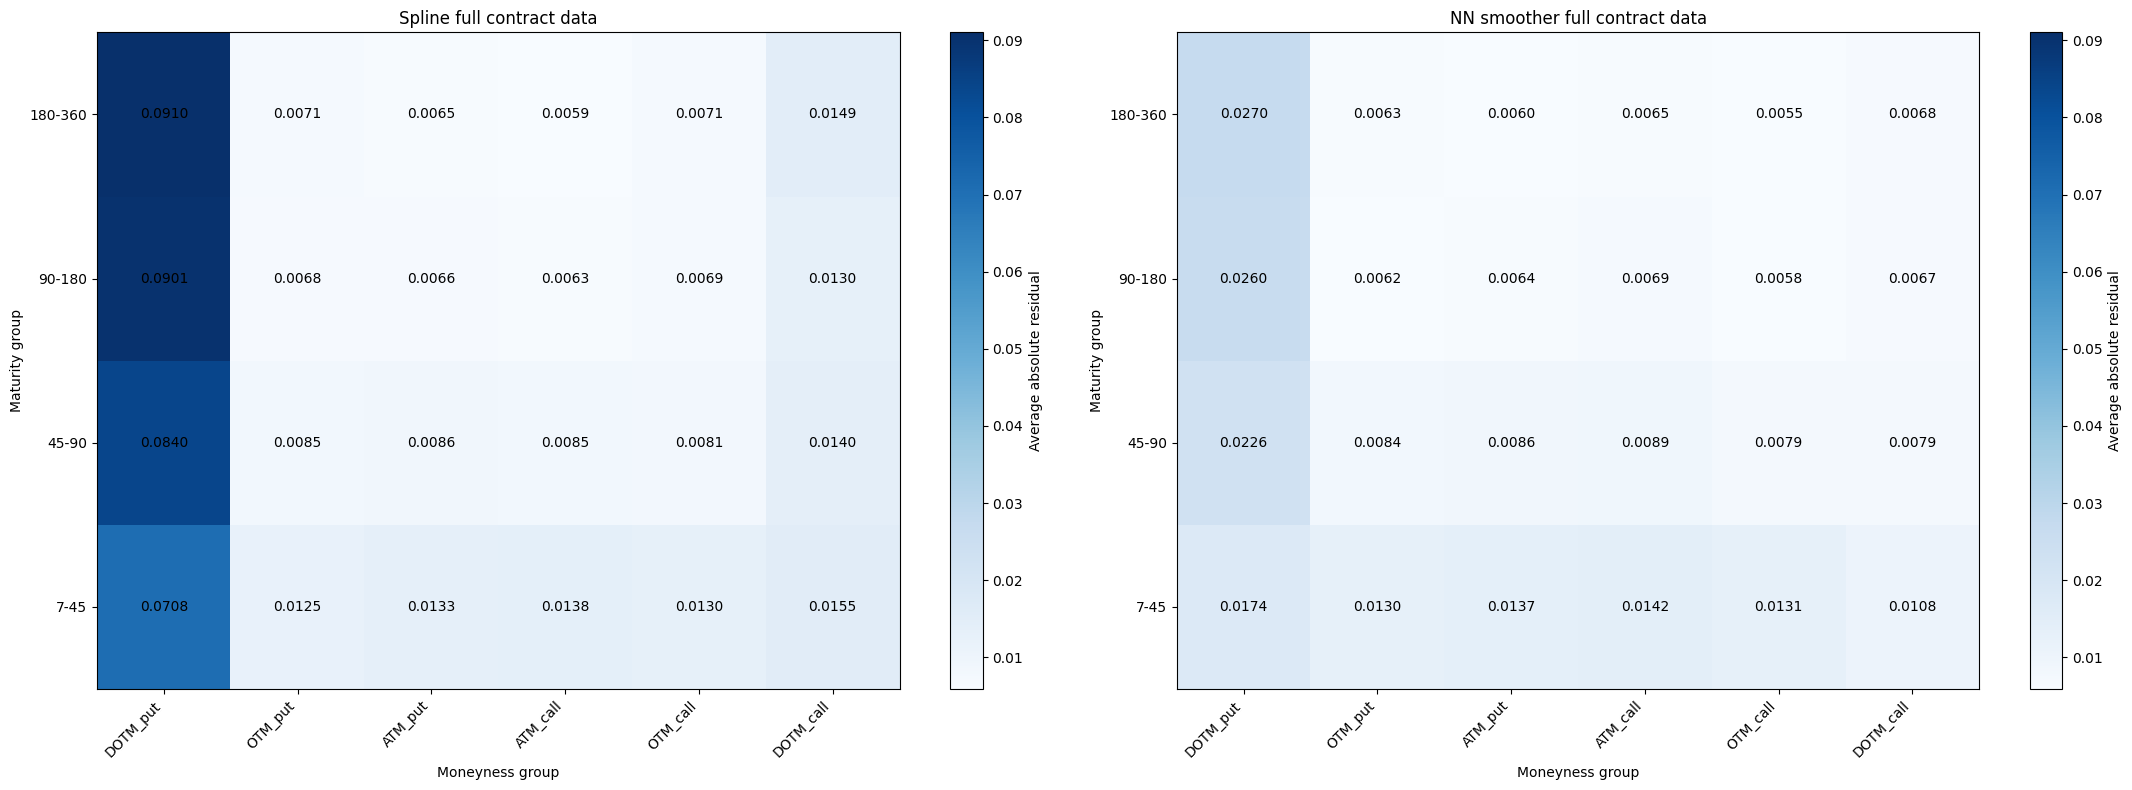

In [318]:
# Specify all dates
full_dates = pd.to_datetime(loss_df_full_mse.index).date

# Set plotting environment
fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# Filter spline full-contract data
x_spline_hm = x_test_full_spline[
    pd.to_datetime(x_test_full_spline["quote_date"]).dt.date.isin(full_dates)
].copy()
dates_spline_hm = np.sort(x_spline_hm["quote_date"].unique())

# Call the heatmap function
data_heatmap_spline_full, heatmap_table_spline_full = make_state_model_residual_heatmap(
    x_spline_hm,
    dates_spline_hm,
    at_pred_spline[:, n_train_dates_spline:n_train_dates_spline + len(dates_spline_hm)],
    prepare_groups_spline,
    title="Spline full contract data",
    ax=axes[0],
    show=False)

# Align the two color bars
vmin_spline = heatmap_table_spline_full.min().min()
vmax_spline = heatmap_table_spline_full.max().max()

# Filter smoother full-contract data
data_heatmap_nn_full = x_test_nn_eval[
    pd.to_datetime(x_test_nn_eval["quote_date"]).dt.date.isin(full_dates)
].copy()

# Compute average residuals
data_heatmap_nn_full["iv_pred"] = data_heatmap_nn_full["iv_nn"]
data_heatmap_nn_full["residual"] = data_heatmap_nn_full["iv_fun"] - data_heatmap_nn_full["iv_pred"]
data_heatmap_nn_full["abs_residual"] = np.abs(data_heatmap_nn_full["residual"])

# Call heatmap function
heatmap_table_nn_full = make_residual_heatmap(
    data_heatmap_nn_full,
    title="NN smoother full contract data",
    ax=axes[1],
    show=False,
    vmin=vmin_spline,
    vmax=vmax_spline)

# Plot the result
fig.tight_layout()
plt.savefig("/Users/euanbronsky/Downloads/heatmap.smoother2.png", bbox_inches="tight")
plt.show()

# **2. STATISTICAL TESTS**

# **2.1 Diebold-Mariano test**

-------------------------------

The Diebold and Mariano (2002) test is used to compare the predictive accuracy of two competing forecasting
models. It does this by looking at the loss differential $dt = L(e_{1,t}) − L(e_{2,t})$, where $L(e_{1,t})$ and $L(e_{2,t})$ are
the forecast losses of model 1 and model 2, respectively. The null hypothesis is $H0 : \mathbb{E}[dt] = 0$, meaning the
two models have equal expected predictive accuracy. The alternative hypothesis is $HA : \mathbb{E}[dt] = 0$, meaning
the models differ in expected predictive accuracy. If $\mathbb{E}[dt] > 0$, model 2 performs better on average because
model 1 has higher loss, and vice versa. The test statistic reads:

$$DM = \frac{\bar d}{\sqrt{\hat S_d / T}}$$

Because forecast errors, and therefore loss differentials, can be serially correlated, the variance of $\bar d$ is estimated using a heteroskedasticity and autocorrelation consistent estimator, $\hat S_d = \hat \gamma_0 + 2 \sum^{h-1}_{j=1} \hat \gamma_j$.

- **Diebold-Mariano function**

In [319]:
# Diebold-Mariano test function
def dm_test_loss(loss_model, loss_benchmark, lag=5):

    # Compute the loss differential
    loss_diff = np.asarray(loss_model) - np.asarray(loss_benchmark)

    # Length of the series, mean differential, and demean
    T = len(loss_diff)
    d_bar = np.mean(loss_diff)
    u = loss_diff - d_bar

    # Average squared deviation
    lrv = np.mean(u * u)

    # HAC standard errors
    for j in range(1, lag + 1):

        # Compute gamma and autocovariance corrections
        gamma = np.mean(u[j:] * u[:-j])
        lrv += 2 * (1 - j / (lag + 1)) * gamma

    # Compute standard error, test statistic, and p-value
    se = np.sqrt(lrv / T)
    dm_stat = d_bar / se
    p_value = 2 * (1 - norm.cdf(np.abs(dm_stat)))

    # Return the results
    return dm_stat, p_value

- **Create table for comparison**

In [321]:
# DM table function
def dm_table(loss_df, benchmark="VAR", lag=5):

    # Create empty list
    out = []

    # Loop over all models in the loss DF
    for name in loss_df.columns:

        # Skip the benchmark model itself
        if name == benchmark:
            continue

        # Run the Dm test
        dm_stat, p_value = dm_test_loss(
            loss_df[name].to_numpy(),
            loss_df[benchmark].to_numpy(),
            lag=lag)

        # Append result to list
        out.append([name, dm_stat, p_value])

    # Return the results
    return pd.DataFrame(out, columns=["model", "DM statistic", "p-value"])

- **Bucketed results: all regions**

In [322]:
# Create covid mask
dates = pd.Series(pd.to_datetime(loss_df_bucketed_mse.index), index=loss_df_bucketed_mse.index)
covid = dates.between("2020-01-01", "2022-12-31")

# Loop over the loss metrics
for loss_name, loss_df in {
    "MSE": loss_df_bucketed_mse,
    "MAE": loss_df_bucketed_mae}.items():

    # Full sample
    print(f"\nFull sample {loss_name}")
    print(dm_table(loss_df, benchmark="VAR"))

    # Non-COVID
    print(f"\nNon-COVID period {loss_name}")
    print(dm_table(loss_df.loc[~covid], benchmark="VAR"))

    # COVID
    print(f"\nCOVID period {loss_name}")
    print(dm_table(loss_df.loc[covid], benchmark="VAR"))


Full sample MSE
    model  DM statistic       p-value
0   Basic     -4.914079  8.920062e-07
1      OU      3.396997  6.812972e-04
2  Spline     -6.038321  1.557265e-09

Non-COVID period MSE
    model  DM statistic       p-value
0   Basic     -4.855268  1.202239e-06
1      OU      2.544998  1.092783e-02
2  Spline     -7.385804  1.514344e-13

COVID period MSE
    model  DM statistic       p-value
0   Basic     -4.332170  1.476470e-05
1      OU      3.013369  2.583645e-03
2  Spline     -5.048743  4.447256e-07

Full sample MAE
    model  DM statistic       p-value
0   Basic     -8.245349  2.220446e-16
1      OU      4.104879  4.045273e-05
2  Spline    -13.930106  0.000000e+00

Non-COVID period MAE
    model  DM statistic       p-value
0   Basic     -5.033176  4.824187e-07
1      OU      2.181211  2.916782e-02
2  Spline     -9.469082  0.000000e+00

COVID period MAE
    model  DM statistic       p-value
0   Basic     -6.834337  8.238521e-12
1      OU      3.526558  4.209987e-04
2  Spline   

- **Bucketed results: DOTM put region**

In [323]:
# Specify group
group = "DOTM_put"

# Align MSE losses
loss_region_bucketed_mse = align_losses({
    "Basic": daily_loss(x_test, iv_pred_basic, "mse", group=group),
    "VAR": daily_loss(x_test_var, iv_pred_test_var, "mse", group=group),
    "OU": daily_loss(x_test, iv_pred_test_ou, "mse", group=group),
    "Spline": daily_loss(x_test_spline, iv_pred_test_spline, "mse", group=group)})

# ALign MAE losses
loss_region_bucketed_mae = align_losses({
    "Basic": daily_loss(x_test, iv_pred_basic, "mae", group=group),
    "VAR": daily_loss(x_test_var, iv_pred_test_var, "mae", group=group),
    "OU": daily_loss(x_test, iv_pred_test_ou, "mae", group=group),
    "Spline": daily_loss(x_test_spline, iv_pred_test_spline, "mae", group=group)})

# Loop over the metrics
for loss_name, loss_df in {
    "MSE": loss_region_bucketed_mse,
    "MAE": loss_region_bucketed_mae}.items():

    # Create mask
    dates = pd.Series(pd.to_datetime(loss_df.index), index=loss_df.index)
    covid = dates.between("2020-01-01", "2022-12-31")

    # Full sample
    print(f"\n{group} Full sample {loss_name}")
    print(dm_table(loss_df, benchmark="VAR"))

    # Non-COVID
    print(f"\n{group} Non-COVID period {loss_name}")
    print(dm_table(loss_df.loc[~covid], benchmark="VAR"))

    # COVID
    print(f"\n{group} COVID period {loss_name}")
    print(dm_table(loss_df.loc[covid], benchmark="VAR"))


DOTM_put Full sample MSE
    model  DM statistic   p-value
0   Basic     -4.660400  0.000003
1      OU      0.174715  0.861303
2  Spline     -0.021766  0.982635

DOTM_put Non-COVID period MSE
    model  DM statistic       p-value
0   Basic    -10.809216  0.000000e+00
1      OU     -5.215599  1.832241e-07
2  Spline     -2.892430  3.822747e-03

DOTM_put COVID period MSE
    model  DM statistic   p-value
0   Basic     -4.053958  0.000050
1      OU      2.077549  0.037751
2  Spline      0.418317  0.675716

DOTM_put Full sample MAE
    model  DM statistic       p-value
0   Basic    -10.611477  0.000000e+00
1      OU    -10.431438  0.000000e+00
2  Spline     -5.788018  7.122189e-09

DOTM_put Non-COVID period MAE
    model  DM statistic       p-value
0   Basic     -7.163478  7.864820e-13
1      OU     -9.250350  0.000000e+00
2  Spline     -6.345567  2.216083e-10

DOTM_put COVID period MAE
    model  DM statistic       p-value
0   Basic     -9.290593  0.000000e+00
1      OU     -6.476443  9.3

- **Full contract results: all regions**

In [324]:
# Loop over loss metrics
for loss_name, loss_df in {
    "MSE": loss_df_full_mse,
    "MAE": loss_df_full_mae}.items():

    # Create masks
    dates = pd.Series(pd.to_datetime(loss_df.index), index=loss_df.index)
    covid = dates.between("2020-01-01", "2022-12-31")
    non_2023 = dates.dt.year != 2023

    # Full sample
    print(f"\nFull sample {loss_name}")
    print(dm_table(loss_df, benchmark="VAR"))

    # COVID
    print(f"\nCOVID period {loss_name}")
    print(dm_table(loss_df.loc[covid], benchmark="VAR"))

    # Excluding 2023
    print(f"\nExcluding 2023 {loss_name}")
    print(dm_table(loss_df.loc[non_2023], benchmark="VAR"))


Full sample MSE
    model  DM statistic   p-value
0      OU     -1.583733  0.113254
1  Spline     -1.601426  0.109283
2      NN     -1.637434  0.101540

COVID period MSE
    model  DM statistic   p-value
0      OU      0.734998  0.462341
1  Spline     -4.615060  0.000004
2      NN     -9.247735  0.000000

Excluding 2023 MSE
    model  DM statistic   p-value
0      OU      0.836771  0.402721
1  Spline     -2.958492  0.003091
2      NN     -9.136459  0.000000

Full sample MAE
    model  DM statistic   p-value
0      OU     -1.342130  0.179554
1  Spline     -2.441659  0.014620
2      NN    -10.386109  0.000000

COVID period MAE
    model  DM statistic   p-value
0      OU      4.077162  0.000046
1  Spline     -4.464110  0.000008
2      NN    -18.141489  0.000000

Excluding 2023 MAE
    model  DM statistic   p-value
0      OU      4.592967  0.000004
1  Spline     -1.097155  0.272574
2      NN    -18.854667  0.000000


- **Full contract results: DOTM put region**

In [325]:
# ALign MSE losses
loss_region_full_mse = align_losses({
    "VAR": daily_loss(x_test_full_var, iv_pred_test_full_var, "mse", group=group),
    "OU": daily_loss(x_test_full_ou, iv_pred_test_full_ou, "mse", group=group),
    "Spline": daily_loss(x_test_full_spline, iv_pred_test_full_spline, "mse", group=group),
    "NN": daily_loss(x_test_nn_eval, iv_pred_test_nn, "mse", group=group)})

# Align MAE losses
loss_region_full_mae = align_losses({
    "VAR": daily_loss(x_test_full_var, iv_pred_test_full_var, "mae", group=group),
    "OU": daily_loss(x_test_full_ou, iv_pred_test_full_ou, "mae", group=group),
    "Spline": daily_loss(x_test_full_spline, iv_pred_test_full_spline, "mae", group=group),
    "NN": daily_loss(x_test_nn_eval, iv_pred_test_nn, "mae", group=group)})

# Loop over loss metrics
for loss_name, loss_df in {
    "MSE": loss_region_full_mse,
    "MAE": loss_region_full_mae}.items():

    # Create masks
    dates = pd.Series(pd.to_datetime(loss_df.index), index=loss_df.index)
    covid = dates.between("2020-01-01", "2022-12-31")
    non_2023 = dates.dt.year != 2023

    # Full sample
    print(f"\n{group} Full sample {loss_name}")
    print(dm_table(loss_df, benchmark="VAR"))

    # COVID
    print(f"\n{group} COVID period {loss_name}")
    print(dm_table(loss_df.loc[covid], benchmark="VAR"))

    # Excluding 2023
    print(f"\n{group} Excluding 2023 {loss_name}")
    print(dm_table(loss_df.loc[non_2023], benchmark="VAR"))


DOTM_put Full sample MSE
    model  DM statistic   p-value
0      OU     -1.606748  0.108110
1  Spline     -1.624443  0.104281
2      NN     -1.670137  0.094892

DOTM_put COVID period MSE
    model  DM statistic   p-value
0      OU      0.661742  0.508136
1  Spline     -4.117841  0.000038
2      NN     -9.407267  0.000000

DOTM_put Excluding 2023 MSE
    model  DM statistic   p-value
0      OU      0.757498  0.448752
1  Spline     -2.619126  0.008816
2      NN     -9.224047  0.000000

DOTM_put Full sample MAE
    model  DM statistic   p-value
0      OU     -1.372798  0.169815
1  Spline     -0.510764  0.609516
2      NN     -9.425245  0.000000

DOTM_put COVID period MAE
    model  DM statistic   p-value
0      OU      3.637746  0.000275
1  Spline     -1.020869  0.307316
2      NN    -14.731390  0.000000

DOTM_put Excluding 2023 MAE
    model  DM statistic  p-value
0      OU      4.108007  0.00004
1  Spline      1.653644  0.09820
2      NN    -15.321087  0.00000


- **Bucketed data pairwise DM heatmaps**

In [334]:
# Pairwise Diebold-Mariano test function
def pairwise_dm_matrices(losses):

    # Extract the model names from the dictionary and store them as a list
    names = list(losses.keys())

    # Create two empty square DataFrames
    dm_mat = pd.DataFrame(index=names, columns=names, dtype=float)
    p_mat = pd.DataFrame(index=names, columns=names, dtype=float)

    # Loop to fill the pairwise DM matrix
    for i in names:
        for j in names:

            # If row and column model are the same, do not run DM test
            if i == j:
                dm_mat.loc[i, j] = np.nan
                p_mat.loc[i, j] = np.nan

            # Else extract the DM results
            else:

                # Obtain common dates
                common = losses[i].index.intersection(losses[j].index)

                # Apply DM test
                dm_stat, p_value = dm_test_loss(
                    losses[i].loc[common].to_numpy(),
                    losses[j].loc[common].to_numpy())

                # Store the DM statistic and p-value
                dm_mat.loc[i, j] = dm_stat
                p_mat.loc[i, j] = p_value

    # Return the results
    return dm_mat, p_mat, names

In [335]:
# Significance stars helper function
def significance_stars(p):
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.10:
        return "*"
    else:
        return ""

In [336]:
# Heatmap drawing function
def add_dm_heatmap(ax, dm_mat, p_mat, names, title, cmap):

    # Find the largest absolute DM statistic in the matrix, ignore the NaN
    v = np.nanmax(np.abs(dm_mat.to_numpy(dtype=float)))
    color_norm = TwoSlopeNorm(vmin=-v, vcenter=0, vmax=v)

    # Draw the heatmap
    im = ax.imshow(dm_mat.astype(float), cmap=cmap, norm=color_norm)

    # Set x- and y-axis specifics
    ax.set_xticks(range(len(names)))
    ax.set_yticks(range(len(names)))
    ax.set_xticklabels(names, rotation=45, ha="right")
    ax.set_yticklabels(names)

    # Write text inside each heatmap cell
    for r in range(len(names)):
        for c in range(len(names)):

            # Check whether cell is missing (diagonal), write a - there
            if pd.isna(dm_mat.iloc[r, c]):
                ax.text(c, r, "-", ha="center", va="center", fontsize=8)
            else:
                # Get the p-value and convert it into stars
                p = p_mat.iloc[r, c]
                stars = significance_stars(p)

                # Write the DM statistic and p-value inside the cell
                ax.text(c, r, f"{dm_mat.iloc[r, c]:.2f}{stars}\n({p:.3f})", ha="center", va="center", fontsize=8)

    # Set the title
    ax.set_title(title)

    # Return the result
    return im

- **Pairwise DM tests aggregate data**

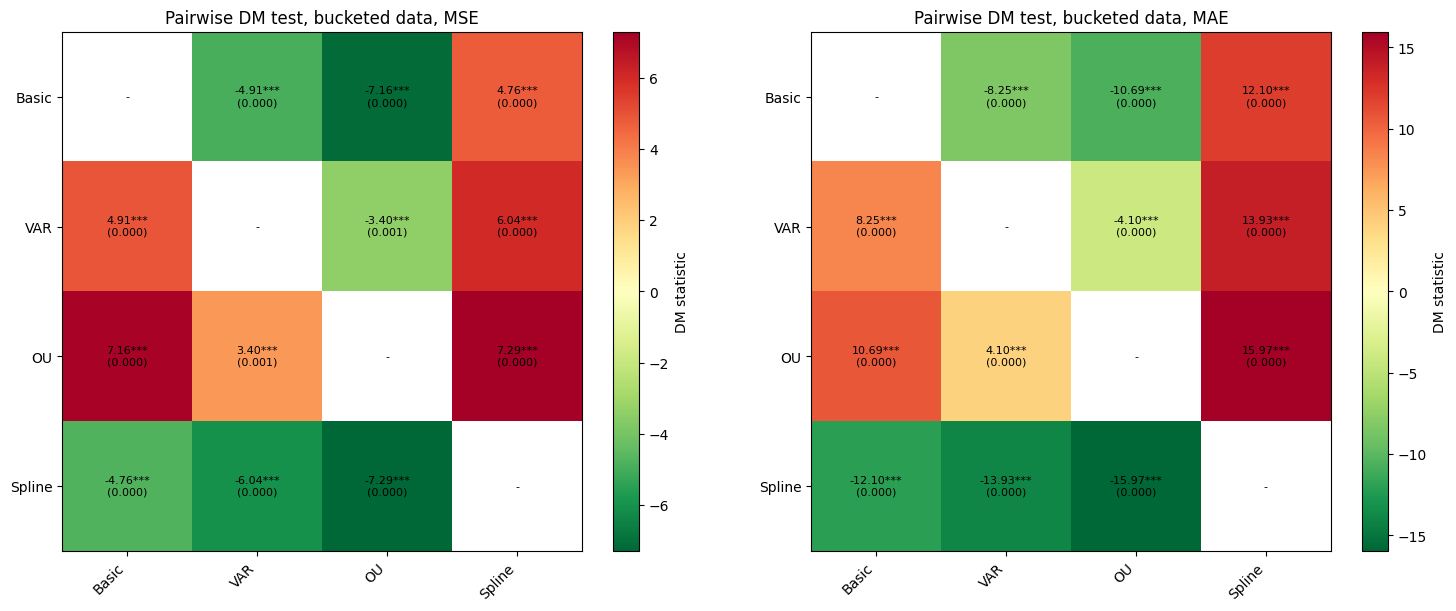

In [337]:
# Apply bucketed pairwise DM tests
dm_mse, p_mse, names = pairwise_dm_matrices({
    "Basic": loss_df_bucketed_mse["Basic"],
    "VAR": loss_df_bucketed_mse["VAR"],
    "OU": loss_df_bucketed_mse["OU"],
    "Spline": loss_df_bucketed_mse["Spline"]})

# Apply ful-contract data pairwise DM tests
dm_mae, p_mae, _ = pairwise_dm_matrices({
    "Basic": loss_df_bucketed_mae["Basic"],
    "VAR": loss_df_bucketed_mae["VAR"],
    "OU": loss_df_bucketed_mae["OU"],
    "Spline": loss_df_bucketed_mae["Spline"]})

# Specify the colormap
cmap = plt.colormaps["RdYlGn_r"].copy()
cmap.set_bad("white")

# Set plotting environment
fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)

# Draw the heatmap for MSE and MAE and store result
im_mse = add_dm_heatmap(axes[0], dm_mse, p_mse, names, "Pairwise DM test, bucketed data, MSE", cmap)
im_mae = add_dm_heatmap(axes[1], dm_mae, p_mae, names, "Pairwise DM test, bucketed data, MAE", cmap)

# Set the colorbar
fig.colorbar(im_mse, ax=axes[0], label="DM statistic")
fig.colorbar(im_mae, ax=axes[1], label="DM statistic")

# Plot the results
plt.savefig("/Users/euanbronsky/Downloads/heatmap.bucketed.png", bbox_inches='tight')
plt.show()

- **Pairwise DM tests region-specific data**

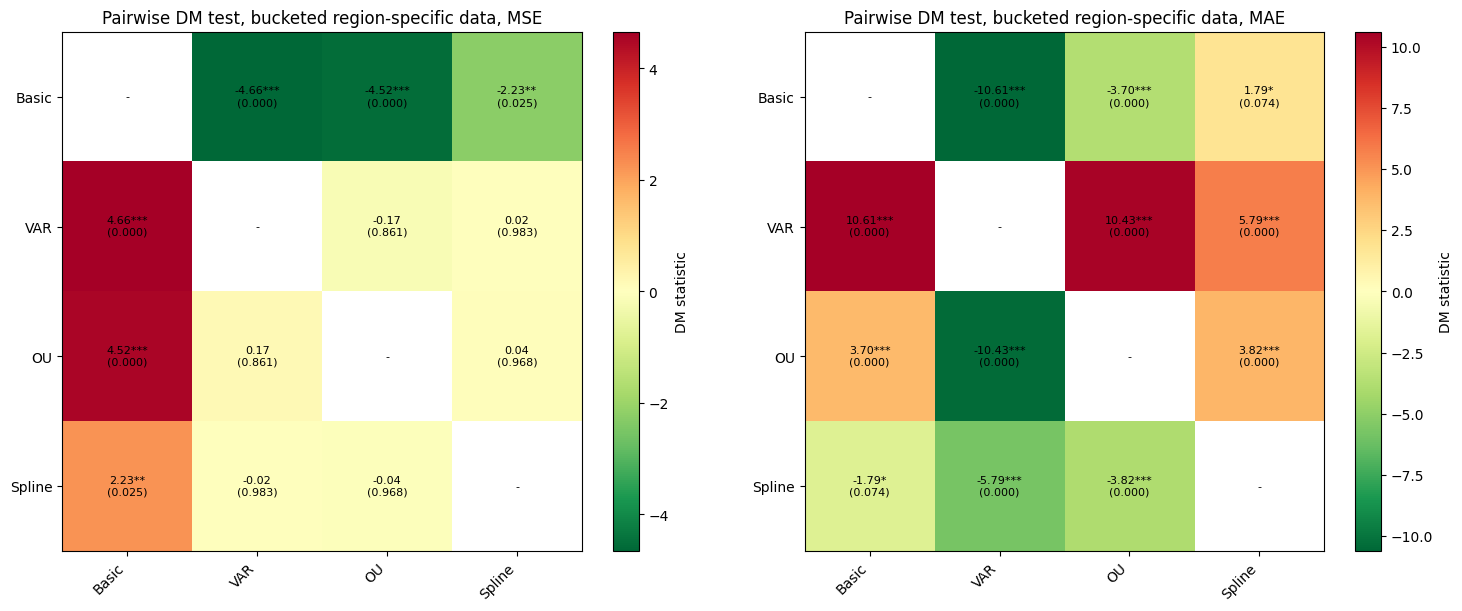

In [339]:
# Apply bucketed region-specific pairwise DM tests based on MSE
dm_mse_region, p_mse_region, names_region = pairwise_dm_matrices({
    "Basic": loss_region_bucketed_mse["Basic"],
    "VAR": loss_region_bucketed_mse["VAR"],
    "OU": loss_region_bucketed_mse["OU"],
    "Spline": loss_region_bucketed_mse["Spline"]})

# Apply bucketed region-specific pairwise DM tests based on MAE
dm_mae_region, p_mae_region, _ = pairwise_dm_matrices({
    "Basic": loss_region_bucketed_mae["Basic"],
    "VAR": loss_region_bucketed_mae["VAR"],
    "OU": loss_region_bucketed_mae["OU"],
    "Spline": loss_region_bucketed_mae["Spline"]})

# Specify the colormap
cmap = plt.colormaps["RdYlGn_r"].copy()
cmap.set_bad("white")

# Set plotting environment
fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)

# Draw the heatmap for MSE and store result
im_mse = add_dm_heatmap(axes[0], dm_mse_region, p_mse_region, names_region, "Pairwise DM test, bucketed region-specific data, MSE", cmap)

# Draw the heatmap for MAE and store result
im_mae = add_dm_heatmap(axes[1], dm_mae_region, p_mae_region, names_region, "Pairwise DM test, bucketed region-specific data, MAE", cmap)

# Set the colorbar
fig.colorbar(im_mse, ax=axes[0], label="DM statistic")
fig.colorbar(im_mae, ax=axes[1], label="DM statistic")

# Plot the results
plt.savefig("/Users/euanbronsky/Downloads/heatmap.bucketed.region.png", bbox_inches="tight")
plt.show()

- **Full contract data pairwise DM heatmaps**

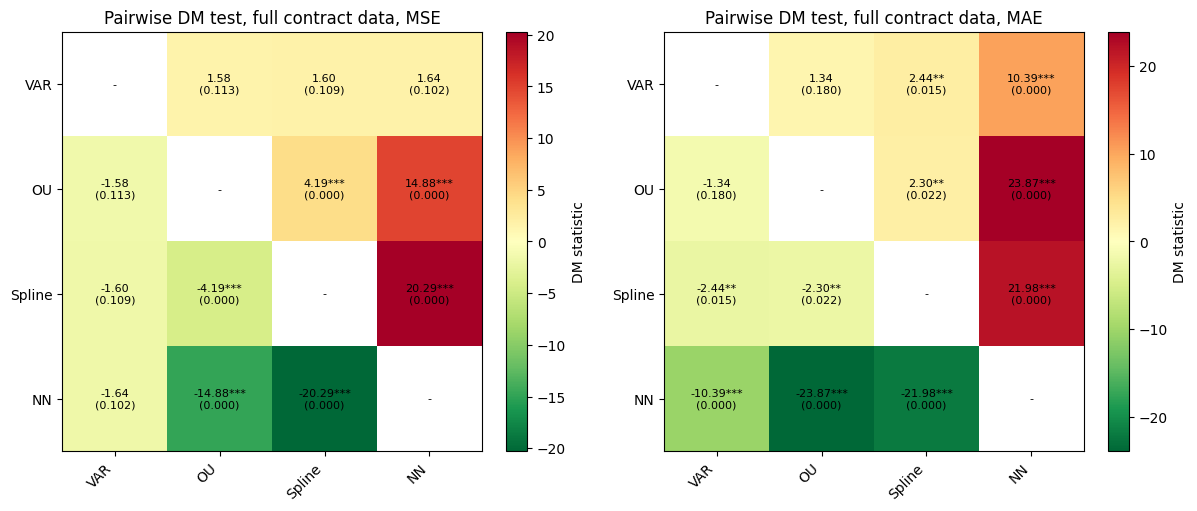

In [340]:
# Full-contract data MSE pairwise DM tests
dm_mse_full, p_mse_full, names_full = pairwise_dm_matrices({
    "VAR": loss_df_full_mse["VAR"],
    "OU": loss_df_full_mse["OU"],
    "Spline": loss_df_full_mse["Spline"],
    "NN": loss_df_full_mse["NN"]})

# Full contract data MAE pairwise DM tests
dm_mae_full, p_mae_full, _ = pairwise_dm_matrices({
    "VAR": loss_df_full_mae["VAR"],
    "OU": loss_df_full_mae["OU"],
    "Spline": loss_df_full_mae["Spline"],
    "NN": loss_df_full_mae["NN"]})

# Specify the colormap
cmap = plt.colormaps["RdYlGn_r"].copy()
cmap.set_bad("white")

# Set plotting environment
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

# Draw the heatmap for MSE and store result
im_mse = add_dm_heatmap(axes[0], dm_mse_full, p_mse_full, names_full, "Pairwise DM test, full contract data, MSE", cmap)

# Draw the heatmap for MAE and store result
im_mae = add_dm_heatmap(axes[1], dm_mae_full, p_mae_full, names_full, "Pairwise DM test, full contract data, MAE", cmap)

# Set the colorbar
fig.colorbar(im_mse, ax=axes[0], label="DM statistic")
fig.colorbar(im_mae, ax=axes[1], label="DM statistic")

# Plot the results
plt.savefig("/Users/euanbronsky/Downloads/heatmap.non.bucketed3.png", bbox_inches="tight")
plt.show()

- **Full contract data region-specific pairwise DM tests**

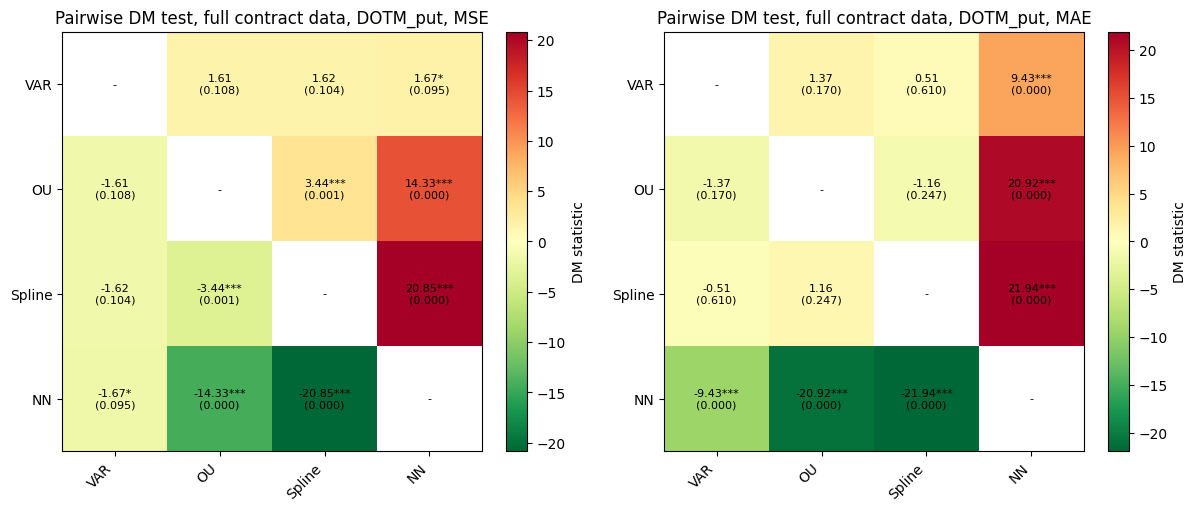

In [341]:
# Full-contract region-specific MSE pairwise DM tests
dm_mse_full_region, p_mse_full_region, names_full_region = pairwise_dm_matrices({
    "VAR": loss_region_full_mse["VAR"],
    "OU": loss_region_full_mse["OU"],
    "Spline": loss_region_full_mse["Spline"],
    "NN": loss_region_full_mse["NN"]})

# Full-contract region-specific MAE pairwise DM tests
dm_mae_full_region, p_mae_full_region, _ = pairwise_dm_matrices({
    "VAR": loss_region_full_mae["VAR"],
    "OU": loss_region_full_mae["OU"],
    "Spline": loss_region_full_mae["Spline"],
    "NN": loss_region_full_mae["NN"]})

# Specify the colormap
cmap = plt.colormaps["RdYlGn_r"].copy()
cmap.set_bad("white")

# Set plotting environment
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

# Draw the heatmap for MSE and store result
im_mse = add_dm_heatmap(axes[0], dm_mse_full_region, p_mse_full_region, names_full_region, f"Pairwise DM test, full contract data, {region}, MSE", cmap)

# Draw the heatmap for MAE and store result
im_mae = add_dm_heatmap(axes[1], dm_mae_full_region, p_mae_full_region, names_full_region, f"Pairwise DM test, full contract data, {region}, MAE", cmap)

# Set the colorbar
fig.colorbar(im_mse, ax=axes[0], label="DM statistic")
fig.colorbar(im_mae, ax=axes[1], label="DM statistic")

# Plot the results
plt.savefig("/Users/euanbronsky/Downloads/heatmap.full.region.bucketed.png", bbox_inches="tight")
plt.show()

# **2.2 Model Confidence Set**

---------------------

The Model Confidence Set procedure of Hansen et al. (2011)} provides a formal method for eliminating inferior models without asymptotic size inflation, yielding a final set of models with Equal Predictive Ability at a chosen confidence level. Starting from a pool $\mathcal{M}$ of candidate models with losses $L_{m, T+s}$, pairwise loss differentials $d_{m,m',T+s}$ are computed for models $m$ and $m'$ at time $T+s$. The objective is to identify the subset $\mathcal{M}^*_{1-\alpha}$ of models that cannot be statistically distinguished in terms of predictive performance. The null hypothesis is $H_0: \mathbb{E}[d_{m,m',T+s}] = 0, \forall m,m' \in \mathcal{M}^*_{1-\alpha}$. If $H_0$ is rejected, the worst-performing model is removed according to an elimination rule, and the procedure is continued until $H_0$ is accepted. The remaining set $\mathcal{M}^*_{1-\alpha}$ is the Model Confidence Set. The test statistic reads:

$$T_{R, \mathcal{M}} = \max_{m, m' \in \mathcal{M}}|t_{m, m'}|$$

 If the EPA test is rejected, the worst performing model is removed from the set, and the test is repeated on the reduced model set. This elimination procedure continues until the EPA null is no longer rejected. The remaining models then form the MCS $\mathcal{M}_{1-\alpha}^*$ which contains the models that are statistically indistinguishable in terms of predictive ability at confidence level $1-\alpha$.

- **HAC helper function**

In [342]:
# HAC standard error function
def hac_se(d, lag=5):

    # Convert to NumPy array
    d = np.asarray(d)

    # Length pf array, mean differential, and demean
    T = len(d)
    d_bar = np.mean(d)
    u = d - d_bar

    # Take mean of outer product
    lrv = np.mean(u * u)

    # HAC standard errors
    for j in range(1, lag + 1):
        gamma = np.mean(u[j:] * u[:-j])
        lrv += 2 * (1 - j / (lag + 1)) * gamma

    # Return the results
    return np.sqrt(lrv / T)

- **Block bootstrap**

In [343]:
# Block bootstrap function
def block_bootstrap_indices(T, block_size, B):

    # Create empty list
    all_indices = []

    # Repeat the procedure B times
    for _ in range(B):

        # Create empty list
        idx = []

        # Keep adding blocks until bootstrap sample has T indices
        while len(idx) < T:

            # Randomly choose where the block starts
            start = np.random.randint(0, T - block_size + 1)

            # Add a consecutive block of indices
            idx.extend(range(start, start + block_size))

        # Cut so it has exactly length T
        all_indices.append(np.array(idx[:T]))

    # Return the results
    return all_indices

- **MCS function**

In [344]:
# MCS function
def mcs_test(loss_df, alpha=0.10, B=1000, block_size=5, lag=5):

    # Create empty list to store models that are removed
    active = list(loss_df.columns)
    eliminated = []

    # Length of series
    T = len(loss_df)

    # Loop until only one model is left or null no longer rejected
    while len(active) > 1:

        # Keep only current active models
        L = loss_df[active]

        # Create empty matric for pairwise test statistics
        t_mat = pd.DataFrame(index=active, columns=active, dtype=float)

        # Loop over every pair of active models
        for i in active:
            for j in active:
                if i == j:
                    # Set the diagonal to be missing
                    t_mat.loc[i, j] = np.nan
                else:
                    # Compute loss differential between model i and j, the mean loss differential, and the HAC SE
                    d = L[i] - L[j]
                    d_mean = d.mean()
                    d_se = hac_se(d, lag=lag)

                    # Store the pairwise t-statistic
                    t_mat.loc[i, j] = d_mean / d_se

        # Compute MCS test statistic
        test_stat = np.nanmax(np.abs(t_mat.to_numpy(dtype=float)))

        # Generate bootstrap time indices using block bootstrap
        boot_indices = block_bootstrap_indices(T, block_size, B)
        boot_stats = []

        # Loop over each bootstrap sample
        for idx in boot_indices:

            # Create bootstrap version of loss matrix
            L_boot = L.iloc[idx].reset_index(drop=True)

            # Create empty pairwise bootstrap t-statistic matrix
            boot_t_mat = pd.DataFrame(index=active, columns=active, dtype=float)

            # Loop over every pair of active models
            for i in active:
                for j in active:
                    if i == j:
                        # Set diagonal to NaN
                        boot_t_mat.loc[i, j] = np.nan
                    else:
                        # Compute original loss differential
                        d = L[i].reset_index(drop=True) - L[j].reset_index(drop=True)
                        d_boot = L_boot[i] - L_boot[j]

                        # Center the bootstrap loss differential around null of EPA
                        d_centered = d_boot.mean() - d.mean()

                        # use HAC SE's
                        d_se = hac_se(d, lag=lag)

                        # Store the bootstrap t-statistic
                        boot_t_mat.loc[i, j] = d_centered / d_se

            # Store the bootstrap max statistic
            boot_stats.append(np.nanmax(np.abs(boot_t_mat.to_numpy(dtype=float))))

        # COmpute bootstrap p-value
        p_value = np.mean(np.array(boot_stats) > test_stat)

        # If p-value larger than significance level, null is not rejected, procedure stops
        if p_value > alpha:
            break

        # Compute average loss for each currently active model
        avg_losses = L.mean()

        # Find model with highest average loss
        worst_model = avg_losses.idxmax()

        # Store the elimination step
        eliminated.append({
            "removed_model": worst_model,
            "average_loss": avg_losses[worst_model],
            "test_statistic": test_stat,
            "p_value": p_value})

        # Remove the worst model
        active.remove(worst_model)

    # Return the results
    return {
        "MCS": active,
        "eliminated": pd.DataFrame(eliminated)}

- **Bucketed data MCS results**

In [345]:
# Set a seed
np.random.seed(123)

# Specify loss dataframes
loss_df_mse = loss_df_bucketed_mse
loss_df_mae = loss_df_bucketed_mae

# Create COVID mask
covid = pd.Series(pd.to_datetime(loss_df_mse.index), index=loss_df_mse.index).between("2020-01-01", "2022-12-31")

# Specify periods
periods = {
    "Full sample": covid == covid,
    "Non-COVID period": ~covid,
    "COVID period": covid}

# Loop over periods
for period_name, period_idx in periods.items():

    # Print the bucketed MSE results
    print(f"\nMCS bucketed {period_name} MSE")
    mcs_mse = mcs_test(loss_df_mse.loc[period_idx], alpha=0.10, B=1000, block_size=5, lag=5)
    print(mcs_mse["MCS"])
    print(mcs_mse["eliminated"])

    # Print the bucketed MAE results
    print(f"\nMCS bucketed {period_name} MAE")
    mcs_mae = mcs_test(loss_df_mae.loc[period_idx], alpha=0.10, B=1000, block_size=5, lag=5)
    print(mcs_mae["MCS"])
    print(mcs_mae["eliminated"])


MCS bucketed Full sample MSE
['Spline']
  removed_model  average_loss  test_statistic  p_value
0            OU      0.000247        7.293768      0.0
1           VAR      0.000240        6.038321      0.0
2         Basic      0.000216        4.761925      0.0

MCS bucketed Full sample MAE
['Spline']
  removed_model  average_loss  test_statistic  p_value
0            OU      0.010686       15.968845      0.0
1           VAR      0.010558       13.930106      0.0
2         Basic      0.010116       12.095536      0.0

MCS bucketed Non-COVID period MSE
['Spline']
  removed_model  average_loss  test_statistic  p_value
0            OU      0.000104        8.815243      0.0
1           VAR      0.000101        7.385804      0.0
2         Basic      0.000092        6.987916      0.0

MCS bucketed Non-COVID period MAE
['Spline']
  removed_model  average_loss  test_statistic  p_value
0            OU      0.007633       10.932693      0.0
1           VAR      0.007554        9.469082      0.0
2

- **Bucketed data region-specific MCS results**

In [346]:
# Set a seed
np.random.seed(123)

# Specify loss dataframes
loss_df_mse = loss_region_bucketed_mse
loss_df_mae = loss_region_bucketed_mae

# Create COVID mask
covid = pd.Series(pd.to_datetime(loss_df_mse.index), index=loss_df_mse.index).between("2020-01-01", "2022-12-31")

# Specify periods
periods = {
    "Full sample": covid == covid,
    "Non-COVID period": ~covid,
    "COVID period": covid}

# Loop over periods
for period_name, period_idx in periods.items():

    # Print the bucketed region-specific MSE results
    print(f"\nMCS bucketed {region} {period_name} MSE")
    mcs_mse = mcs_test(loss_df_mse.loc[period_idx], alpha=0.10, B=1000, block_size=5, lag=5)
    print(mcs_mse["MCS"])
    print(mcs_mse["eliminated"])

    # Print the bucketed region-specific MAE results
    print(f"\nMCS bucketed {region} {period_name} MAE")
    mcs_mae = mcs_test(loss_df_mae.loc[period_idx], alpha=0.10, B=1000, block_size=5, lag=5)
    print(mcs_mae["MCS"])
    print(mcs_mae["eliminated"])


MCS bucketed DOTM_put Full sample MSE
['Basic']
  removed_model  average_loss  test_statistic  p_value
0            OU      0.000313        4.660400    0.000
1           VAR      0.000313        4.660400    0.000
2        Spline      0.000312        2.234497    0.015

MCS bucketed DOTM_put Full sample MAE
['Spline']
  removed_model  average_loss  test_statistic  p_value
0           VAR      0.012213       10.611477    0.000
1            OU      0.011458        3.817288    0.000
2         Basic      0.010994        1.788165    0.063

MCS bucketed DOTM_put Non-COVID period MSE
['Basic', 'Spline']
  removed_model  average_loss  test_statistic  p_value
0           VAR      0.000138       10.809216      0.0
1            OU      0.000123        4.928756      0.0

MCS bucketed DOTM_put Non-COVID period MAE
['Spline']
  removed_model  average_loss  test_statistic  p_value
0           VAR      0.009121        9.250350      0.0
1         Basic      0.008462        4.764998      0.0
2           

- **Full contract data MCS results**

In [347]:
# Period indicators
covid = pd.Series(pd.to_datetime(loss_df_full_mse.index), index=loss_df_full_mse.index).between(
    "2020-01-01", "2022-12-31")
non_2023 = pd.Series(pd.to_datetime(loss_df_full_mse.index), index=loss_df_full_mse.index).dt.year != 2023

# Specify periods
periods = {
    "Full sample": covid == covid,
    "COVID period": covid,
    "Excluding 2023": non_2023}

# Loop over the periods
for period_name, period_idx in periods.items():

    # Print the MSE full contract data test results
    print(f"\nMCS full contract {period_name} MSE")
    mcs_mse = mcs_test(loss_df_full_mse.loc[period_idx], alpha=0.10, B=1000, block_size=5, lag=5)
    print(mcs_mse["MCS"])
    print(mcs_mse["eliminated"])

    # Print the MAE full contract data test results
    print(f"\nMCS full contract {period_name} MAE")
    mcs_mae = mcs_test(loss_df_full_mae.loc[period_idx], alpha=0.10, B=1000, block_size=5, lag=5)
    print(mcs_mae["MCS"])
    print(mcs_mae["eliminated"])


MCS full contract Full sample MSE
['NN']
  removed_model  average_loss  test_statistic  p_value
0           VAR      0.280793       20.287917      0.0
1            OU      0.009923       20.287917      0.0
2        Spline      0.006772       20.287917      0.0

MCS full contract Full sample MAE
['NN']
  removed_model  average_loss  test_statistic  p_value
0           VAR      0.041730       23.873765      0.0
1            OU      0.038362       23.873765      0.0
2        Spline      0.034849       21.976010      0.0

MCS full contract COVID period MSE
['NN']
  removed_model  average_loss  test_statistic  p_value
0            OU      0.013082       14.920352      0.0
1           VAR      0.012248       13.058774      0.0
2        Spline      0.006238       13.058774      0.0

MCS full contract COVID period MAE
['NN']
  removed_model  average_loss  test_statistic  p_value
0            OU      0.045743       20.793597      0.0
1           VAR      0.041979       18.141489      0.0
2    

- **Full contract data MCS region-specific results**

In [348]:
# Period indicators
covid = pd.Series(pd.to_datetime(loss_region_full_mse.index), index=loss_region_full_mse.index).between(
    "2020-01-01", "2022-12-31")
non_2023 = pd.Series(pd.to_datetime(loss_region_full_mse.index), index=loss_region_full_mse.index).dt.year != 2023

# Specify periods
periods = {
    "Full sample": covid == covid,
    "COVID period": covid,
    "Excluding 2023": non_2023}

# Loop over the periods
for period_name, period_idx in periods.items():

    # Print the MSE full contract region-specific test results
    print(f"\nMCS full contract {region} {period_name} MSE")
    mcs_mse = mcs_test(loss_region_full_mse.loc[period_idx], alpha=0.10, B=1000, block_size=5, lag=5)
    print(mcs_mse["MCS"])
    print(mcs_mse["eliminated"])

    # Print the MAE full contract region-specific test results
    print(f"\nMCS full contract {region} {period_name} MAE")
    mcs_mae = mcs_test(loss_region_full_mae.loc[period_idx], alpha=0.10, B=1000, block_size=5, lag=5)
    print(mcs_mae["MCS"])
    print(mcs_mae["eliminated"])


MCS full contract DOTM_put Full sample MSE
['NN']
  removed_model  average_loss  test_statistic  p_value
0           VAR      0.658353       20.847689      0.0
1            OU      0.026722       20.847689      0.0
2        Spline      0.019474       20.847689      0.0

MCS full contract DOTM_put Full sample MAE
['NN']
  removed_model  average_loss  test_statistic  p_value
0           VAR      0.084960       21.941764      0.0
1        Spline      0.081387       21.941764      0.0
2            OU      0.076677       20.919959      0.0

MCS full contract DOTM_put COVID period MSE
['NN']
  removed_model  average_loss  test_statistic  p_value
0            OU      0.035572       14.279496      0.0
1           VAR      0.033612       13.423960      0.0
2        Spline      0.018664       13.423960      0.0

MCS full contract DOTM_put COVID period MAE
['NN']
  removed_model  average_loss  test_statistic  p_value
0            OU      0.093071       17.943107      0.0
1           VAR      0.0

# **2.3 Plots**

- **Store results in dictionary**

In [349]:
# Initialize DataFrame
actual_fitted_residuals_full = {}

# Basic model
df_plot = x_test_full_var.sort_values(["quote_date", "moneyness_group", "maturity_group"]).copy()
df_plot["iv_pred"] = np.asarray(iv_pred_test_full_var)
df_plot["residual"] = df_plot["iv_fun"] - df_plot["iv_pred"]
tmp = df_plot.groupby(pd.to_datetime(df_plot["quote_date"]).dt.date)[["iv_fun", "iv_pred", "residual"]].mean()
actual_fitted_residuals_full["VAR"] = tmp

# OU model
df_plot = x_test_full_ou.sort_values(["quote_date", "moneyness_group", "maturity_group"]).copy()
df_plot["iv_pred"] = np.asarray(iv_pred_test_full_ou)
df_plot["residual"] = df_plot["iv_fun"] - df_plot["iv_pred"]
tmp = df_plot.groupby(pd.to_datetime(df_plot["quote_date"]).dt.date)[["iv_fun", "iv_pred", "residual"]].mean()
actual_fitted_residuals_full["OU"] = tmp

# Spline model
df_plot = x_test_full_spline.sort_values(["quote_date", "moneyness_group", "maturity_group"]).copy()
df_plot["iv_pred"] = np.asarray(iv_pred_test_full_spline)
df_plot["residual"] = df_plot["iv_fun"] - df_plot["iv_pred"]
tmp = df_plot.groupby(pd.to_datetime(df_plot["quote_date"]).dt.date)[["iv_fun", "iv_pred", "residual"]].mean()
actual_fitted_residuals_full["Spline"] = tmp

# Smoother model
df_plot = x_test_nn_eval.sort_values(["quote_date", "moneyness_group", "maturity_group"]).copy()
df_plot["iv_pred"] = df_plot["iv_nn"]
df_plot["residual"] = df_plot["iv_fun"] - df_plot["iv_pred"]
tmp = df_plot.groupby(pd.to_datetime(df_plot["quote_date"]).dt.date)[["iv_fun", "iv_pred", "residual"]].mean()
actual_fitted_residuals_full["NN"] = tmp

- **Align all series to have common dates**


In [350]:
# Align the four time series to the same dates
common_dates = None
for df_plot in actual_fitted_residuals_full.values():
    common_dates = df_plot.index if common_dates is None else common_dates.intersection(df_plot.index)

# Sort the dates chronologically
common_dates = sorted(common_dates)

# Create new dictionary where each model is restricted to the common dates
actual_fitted_residuals_full_aligned = {
    model_name: df_plot.loc[common_dates]
    for model_name, df_plot in actual_fitted_residuals_full.items()}

- **Plot the results**

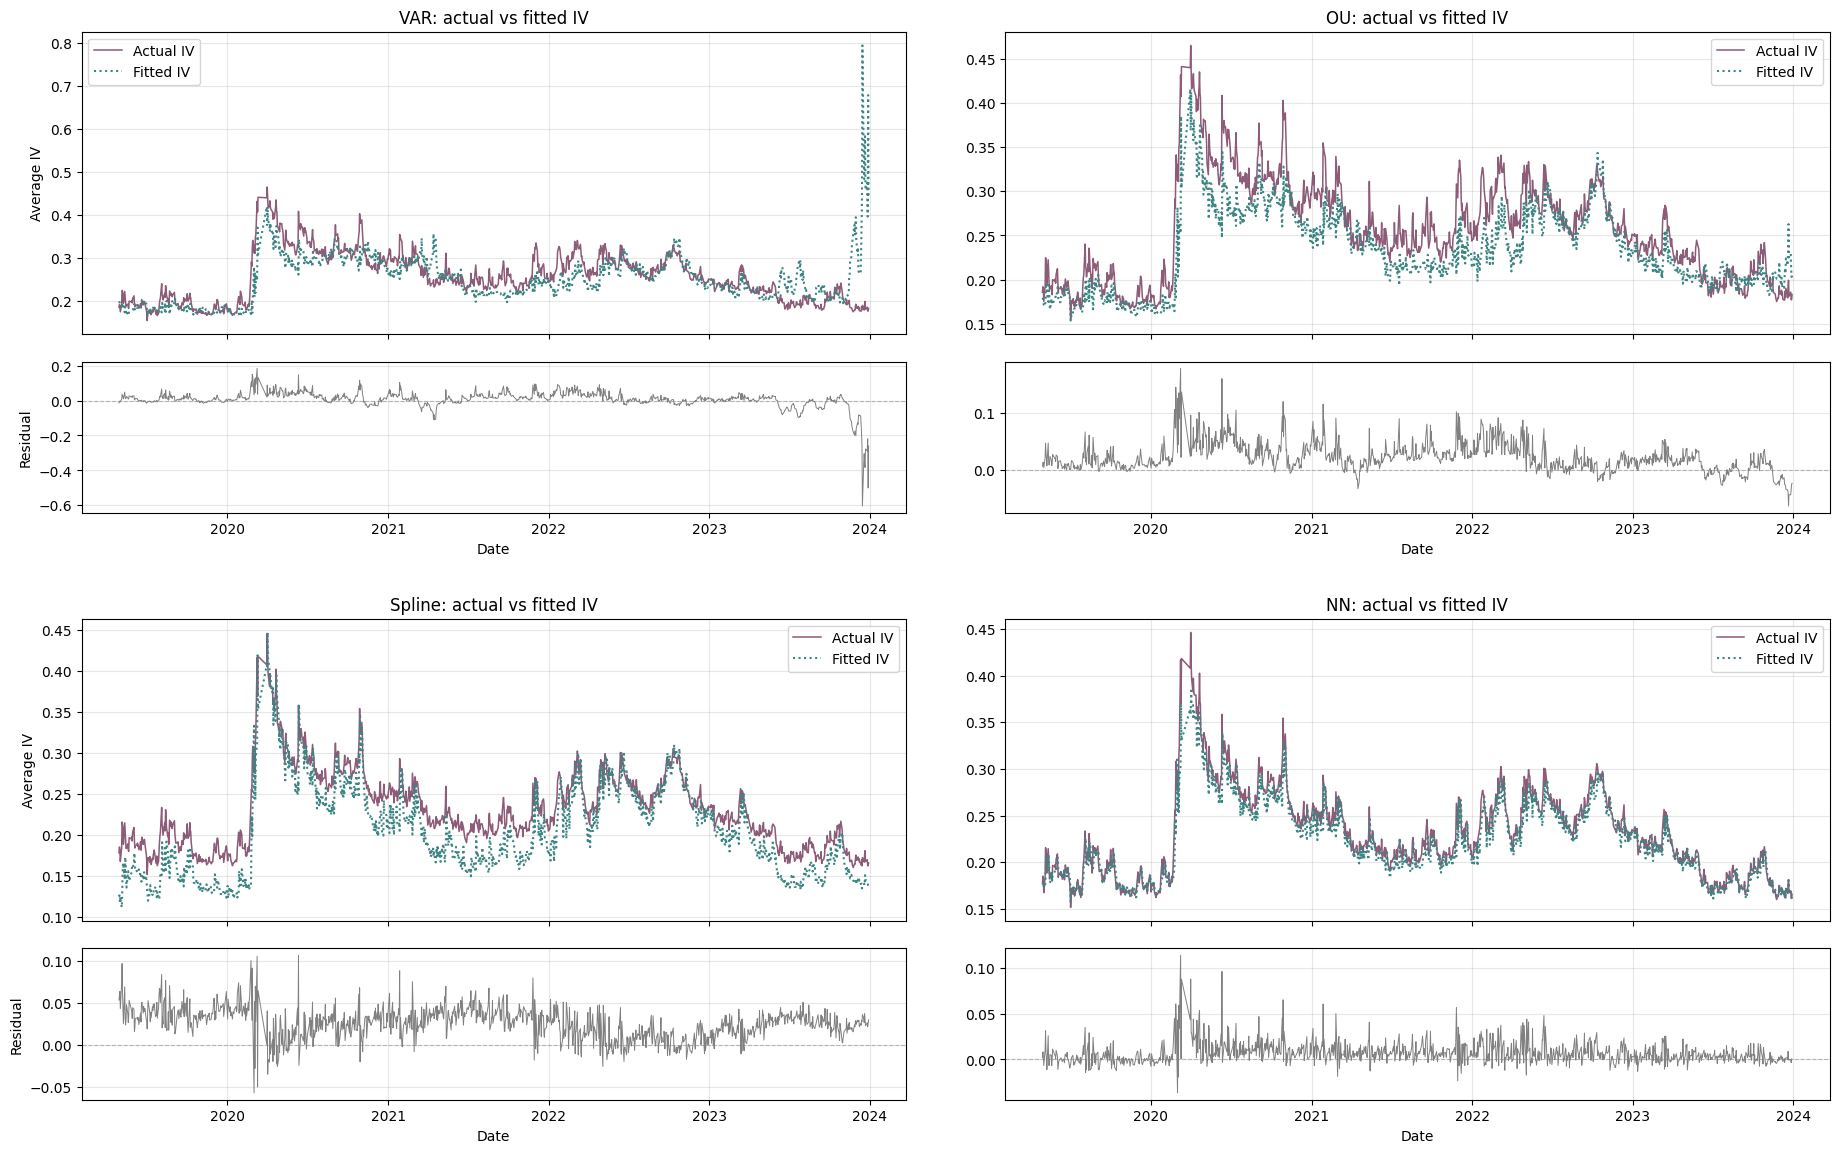

In [352]:
# Set plotting environment
fig = plt.figure(figsize=(19, 12))
outer_grid = fig.add_gridspec(2, 2, wspace=0.12, hspace=0.22)

# Loop to plot the results
for i, (model_name, df_plot) in enumerate(actual_fitted_residuals_full_aligned.items()):

    # Create two stacked plots inside one model panel
    inner_grid = outer_grid[i // 2, i % 2].subgridspec(2, 1, height_ratios=[2, 1], hspace=0.12)

    # Create top and bottom subplots
    ax_top = fig.add_subplot(inner_grid[0])
    ax_bottom = fig.add_subplot(inner_grid[1], sharex=ax_top)

    # Plot the average actual and predicted IV over time
    ax_top.plot(df_plot.index, df_plot["iv_fun"], label="Actual IV", color="#804a69", alpha=0.9, linewidth=1.1)
    ax_top.plot(df_plot.index, df_plot["iv_pred"], label="Fitted IV", color="#3b8583", linestyle=":")

    # Plot average residual over time
    ax_bottom.plot(df_plot.index, df_plot["residual"], label="Residual", color="gray", linewidth=0.7)
    ax_bottom.axhline(0, linestyle="--", linewidth=0.8, color="gray", alpha=0.5)

    # Set specifics
    ax_top.set_title(f"{model_name}: actual vs fitted IV")
    ax_top.grid(True, alpha=0.3)
    ax_bottom.grid(True, alpha=0.3)
    ax_bottom.set_xlabel("Date")
    ax_top.legend()
    plt.setp(ax_top.get_xticklabels(), visible=False)

    # Add y-axis labels only to the left-column panels
    if i % 2 == 0:
        ax_top.set_ylabel("Average IV")
        ax_bottom.set_ylabel("Residual")

# Adjust plots
fig.subplots_adjust(left=0.06, right=0.98, top=0.95, bottom=0.06)

# Plot the results
plt.savefig("/Users/euanbronsky/Downloads/iv.pred.resid3_aligned.png", bbox_inches="tight")
plt.show()

- **Spline and smoother models data**

In [353]:
# Spline model: DOTM put actual, fitted, and residual
df_spline = x_test_full_spline.sort_values(["quote_date", "moneyness_group", "maturity_group"]).copy()

# Obtain residuals
df_spline["quote_date"] = pd.to_datetime(df_spline["quote_date"]).dt.normalize()
df_spline["iv_pred"] = np.asarray(iv_pred_test_full_spline)
df_spline["residual"] = df_spline["iv_fun"] - df_spline["iv_pred"]

# Adjust data
spline_dotm_put = (df_spline[df_spline["moneyness_group"] == "DOTM_put"].groupby("quote_date")[["iv_fun", "iv_pred", "residual"]].mean().sort_index())

# NN model: DOTM put actual, fitted, and residual
df_nn = x_test_nn_eval.sort_values(["quote_date", "moneyness_group", "maturity_group"]).copy()

# Obtain residuals
df_nn["quote_date"] = pd.to_datetime(df_nn["quote_date"]).dt.normalize()
df_nn["iv_pred"] = np.asarray(iv_pred_test_nn)
df_nn["residual"] = df_nn["iv_fun"] - df_nn["iv_pred"]

# Adjust data
nn_dotm_put = (df_nn[df_nn["moneyness_group"] == "DOTM_put"].groupby("quote_date")[["iv_fun", "iv_pred", "residual"]].mean().sort_index())

- **Align the dates**

In [ ]:
# Extract common dates
common_dates = spline_dotm_put.index.intersection(nn_dotm_put.index).sort_values()

# Align dates
spline_dotm_put = spline_dotm_put.loc[common_dates]
nn_dotm_put = nn_dotm_put.loc[common_dates]


- **Plot the results**

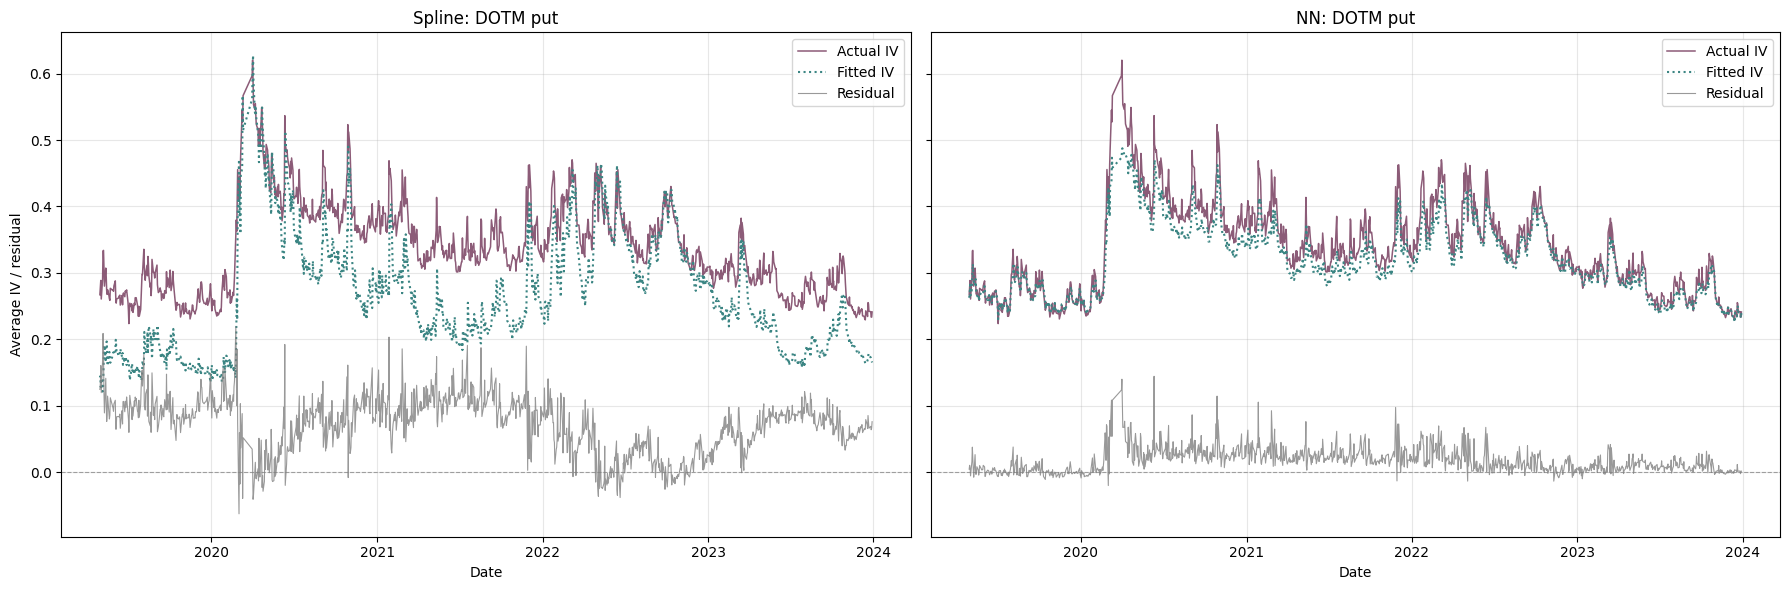

In [354]:
# Set plotting environment
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharex=True, sharey=True)

# Specify plotting data
plot_data = {
    "Spline: DOTM put": spline_dotm_put,
    "NN: DOTM put": nn_dotm_put}

# Loop over the plots
for ax, (title, df_plot) in zip(axes, plot_data.items()):

    # Plot the actual IV
    ax.plot(df_plot.index, df_plot["iv_fun"], label="Actual IV", color="#804a69", alpha=0.9, linewidth=1.1)

    # Plot the predicted IV
    ax.plot(df_plot.index, df_plot["iv_pred"], label="Fitted IV", color="#3b8583", linestyle=":", linewidth=1.5)

    # Plot the residual
    ax.plot(df_plot.index, df_plot["residual"], label="Residual", color="gray", linewidth=0.8, alpha=0.8)

    # Plot horizontal line
    ax.axhline(0, linestyle="--", linewidth=0.8, color="gray", alpha=0.7)

    # Set specifics
    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.grid(True, alpha=0.3)
    ax.legend()

# Set one y-label
axes[0].set_ylabel("Average IV / residual")

# Plot the results
plt.tight_layout()
plt.savefig("/Users/euanbronsky/Downloads/spline_nn_dotm_put_actual_fitted_residual.png", bbox_inches="tight")
plt.show()

# **3. ARBITRAGE VIOLATIONS**

- **VAR model**

In [264]:
# Calendar arbitrage summary for VAR OOS
df_cal_var = x_test_full_var.copy()
df_cal_var["quote_date"] = pd.to_datetime(df_cal_var["quote_date"])
df_cal_var["iv_pred"] = iv_pred_test_full_var

beta_oos_var = at_pred_var[
    :,
    n_train_dates_var:n_train_dates_var + len(dates_test_full_var)
]

dates_test_full_var_dt = pd.to_datetime(dates_test_full_var)

beta_by_date = {
    date: beta_oos_var[:, i]
    for i, date in enumerate(dates_test_full_var_dt)
}

df_cal_var["beta_T"] = df_cal_var["quote_date"].map(lambda d: beta_by_date[d][3])
df_cal_var["beta_MT"] = df_cal_var["quote_date"].map(lambda d: beta_by_date[d][4])

df_cal_var["calendar_derivative"] = (
    df_cal_var["iv_pred"]**2
    * (
        1
        + 2 * df_cal_var["T"] * (
            df_cal_var["beta_T"] + df_cal_var["beta_MT"] * df_cal_var["M"]
        )
    )
)

n_violations = (df_cal_var["calendar_derivative"] < 0).sum()
violation_pct = 100 * (df_cal_var["calendar_derivative"] < 0).mean()

print(f"VAR & {n_violations} ({violation_pct:.2f}\\%)")

VAR & 1758 (0.05\%)


In [265]:
# Butterfly arbitrage summary for VAR OOS
# Implements:
# l_but(k,T) =
# (1 - k*w_k/(2*w))^2
# - (w_k/4)*(1/w + 1/4)
# + w_kk/2

df_but_var = x_test_full_var.copy()
df_but_var["quote_date"] = pd.to_datetime(df_but_var["quote_date"])

df_but_var = df_but_var.sort_values(
    ["quote_date", "moneyness_group", "maturity_group"]
).reset_index(drop=True)

df_but_var["iv_pred"] = iv_pred_test_full_var
df_but_var["w_pred"] = df_but_var["T"] * df_but_var["iv_pred"]**2

beta_oos_var = at_pred_var[
    :,
    n_train_dates_var:n_train_dates_var + len(dates_test_full_var)
]

dates_test_full_var_dt = pd.to_datetime(dates_test_full_var)

beta_by_date = {
    date: beta_oos_var[:, i]
    for i, date in enumerate(dates_test_full_var_dt)
}

df_but_var["beta_M"] = df_but_var["quote_date"].map(lambda d: beta_by_date[d][1])
df_but_var["beta_M2"] = df_but_var["quote_date"].map(lambda d: beta_by_date[d][2])
df_but_var["beta_MT"] = df_but_var["quote_date"].map(lambda d: beta_by_date[d][4])

a = (
    df_but_var["beta_M"]
    + 2 * df_but_var["beta_M2"] * df_but_var["M"]
    + df_but_var["beta_MT"] * df_but_var["T"]
)

w = df_but_var["w_pred"]
k = df_but_var["M"]

w_k = 2 * w * a
w_kk = 4 * w * (a**2 + df_but_var["beta_M2"])

df_but_var["butterfly_condition"] = (
    (1 - k * w_k / (2 * w))**2
    - (w_k / 4) * (1 / w + 1 / 4)
    + w_kk / 2
)

violations = df_but_var["butterfly_condition"] < 0

n_violations = violations.sum()
violation_pct = 100 * violations.mean()

print(f"VAR & {n_violations} ({violation_pct:.2f}\\%)")

VAR & 192 (0.01\%)


- **OU model**

In [266]:
# Calendar arbitrage summary for OU OOS

df_cal_ou = x_test_full_ou.copy()
df_cal_ou["quote_date"] = pd.to_datetime(df_cal_ou["quote_date"])

df_cal_ou = df_cal_ou.sort_values(
    ["quote_date", "moneyness_group", "maturity_group"]
).reset_index(drop=True)

df_cal_ou["iv_pred"] = iv_pred_test_full_ou

beta_oos_ou = at_pred_ou[
    :,
    n_train_dates_ou:n_train_dates_ou + len(dates_test_full_ou)
]

dates_test_full_ou_dt = pd.to_datetime(dates_test_full_ou)

beta_by_date_ou = {
    date: beta_oos_ou[:, i]
    for i, date in enumerate(dates_test_full_ou_dt)
}

df_cal_ou["beta_T"] = df_cal_ou["quote_date"].map(lambda d: beta_by_date_ou[d][3])
df_cal_ou["beta_MT"] = df_cal_ou["quote_date"].map(lambda d: beta_by_date_ou[d][4])

df_cal_ou["calendar_derivative"] = (
    df_cal_ou["iv_pred"]**2
    * (
        1
        + 2 * df_cal_ou["T"] * (
            df_cal_ou["beta_T"] + df_cal_ou["beta_MT"] * df_cal_ou["M"]
        )
    )
)

violations = df_cal_ou["calendar_derivative"] < 0

n_violations = violations.sum()
violation_pct = 100 * violations.mean()

print(f"OU & {n_violations} ({violation_pct:.2f}\\%)")

OU & 2861 (0.09\%)


In [267]:
# Butterfly arbitrage summary for OU OOS
# Implements:
# l_but(k,T) =
# (1 - k*w_k/(2*w))^2
# - (w_k/4)*(1/w + 1/4)
# + w_kk/2

df_but_ou = x_test_full_ou.copy()
df_but_ou["quote_date"] = pd.to_datetime(df_but_ou["quote_date"])

df_but_ou = df_but_ou.sort_values(
    ["quote_date", "moneyness_group", "maturity_group"]
).reset_index(drop=True)

df_but_ou["iv_pred"] = iv_pred_test_full_ou
df_but_ou["w_pred"] = df_but_ou["T"] * df_but_ou["iv_pred"]**2

beta_oos_ou = at_pred_ou[
    :,
    n_train_dates_ou:n_train_dates_ou + len(dates_test_full_ou)
]

dates_test_full_ou_dt = pd.to_datetime(dates_test_full_ou)

beta_by_date_ou = {
    date: beta_oos_ou[:, i]
    for i, date in enumerate(dates_test_full_ou_dt)
}

df_but_ou["beta_M"] = df_but_ou["quote_date"].map(lambda d: beta_by_date_ou[d][1])
df_but_ou["beta_M2"] = df_but_ou["quote_date"].map(lambda d: beta_by_date_ou[d][2])
df_but_ou["beta_MT"] = df_but_ou["quote_date"].map(lambda d: beta_by_date_ou[d][4])

a = (
    df_but_ou["beta_M"]
    + 2 * df_but_ou["beta_M2"] * df_but_ou["M"]
    + df_but_ou["beta_MT"] * df_but_ou["T"]
)

w = df_but_ou["w_pred"]
k = df_but_ou["M"]

w_k = 2 * w * a
w_kk = 4 * w * (a**2 + df_but_ou["beta_M2"])

df_but_ou["butterfly_condition"] = (
    (1 - k * w_k / (2 * w))**2
    - (w_k / 4) * (1 / w + 1 / 4)
    + w_kk / 2
)

violations = df_but_ou["butterfly_condition"] < 0

n_violations = violations.sum()
violation_pct = 100 * violations.mean()

print(f"OU & {n_violations} ({violation_pct:.2f}\\%)")

OU & 52 (0.00\%)


- **Spline model**

In [268]:
# Calendar and butterfly arbitrage summary for Spline OOS
# Uses existing spline OOS predictions from your notebook:
# x_test_full_spline
# iv_pred_test_full_spline

df_spline_arb = x_test_full_spline.copy()
df_spline_arb["quote_date"] = pd.to_datetime(df_spline_arb["quote_date"])

df_spline_arb = df_spline_arb.sort_values(
    ["quote_date", "moneyness_group", "maturity_group", "M", "T"]
).reset_index(drop=True)

df_spline_arb["iv_pred"] = iv_pred_test_full_spline
df_spline_arb["w_pred"] = df_spline_arb["T"] * df_spline_arb["iv_pred"]**2

In [269]:
# Calendar and butterfly arbitrage summary for Spline OOS
# Uses existing spline OOS predictions from your notebook:
# x_test_full_spline
# iv_pred_test_full_spline

df_spline_arb = x_test_full_spline.copy()
df_spline_arb["quote_date"] = pd.to_datetime(df_spline_arb["quote_date"])

df_spline_arb = df_spline_arb.sort_values(
    ["quote_date", "moneyness_group", "maturity_group", "M", "T"]
).reset_index(drop=True)

df_spline_arb["iv_pred"] = iv_pred_test_full_spline
df_spline_arb["w_pred"] = df_spline_arb["T"] * df_spline_arb["iv_pred"]**2

In [270]:
# Calendar arbitrage for spline model
# Fixes duplicate T values before applying np.gradient

calendar_parts = []

for _, group in df_spline_arb.groupby(["quote_date", "moneyness_group"]):
    group_avg = (
        group
        .groupby("T", as_index=False)
        .agg(w_pred=("w_pred", "mean"))
        .sort_values("T")
    )

    if len(group_avg) < 2:
        continue

    group_avg["calendar_derivative"] = np.gradient(
        group_avg["w_pred"].to_numpy(),
        group_avg["T"].to_numpy()
    )

    calendar_parts.append(group_avg)

df_cal_spline = pd.concat(calendar_parts, axis=0)

calendar_violations = df_cal_spline["calendar_derivative"] < 0

n_calendar_violations = calendar_violations.sum()
calendar_violation_pct = 100 * calendar_violations.mean()

print(f"Spline & {n_calendar_violations} ({calendar_violation_pct:.2f}\\%)")

Spline & 6708 (3.18\%)


- **Save the results**

In [281]:
# Store relevant results
models = {
    "Basic": (x_test_full_first, iv_pred_first_full),
    "VAR": (x_test_full_var, iv_pred_test_full_var),
    "OU": (x_test_full_ou, iv_pred_test_full_ou),
    "Spline": (x_test_full_spline, iv_pred_test_full_spline),
    "NN": (x_test_nn_eval, iv_pred_test_nn)}

# Save with Pickle
with open("models.eval.pkl", "wb") as f:
    pickle.dump(models, f)